## Validation of PVade against DuraMAT experimental campaign ##

In [1]:
import pandas as pd
import numpy as np
import yaml
import pickle
import importlib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# spectra
from scipy.signal import welch
from numpy import hanning
import math

# from postprocessing_functions import *
# importlib.reload(postprocessing_functions) # to reload functions without restarting the notebook

In [2]:
pwd

'/kfs2/projects/pvopt/aps_dfd_2024/PVade/postprocessing'

In [5]:
# copying from https://github.com/brookeslawski/scripts/blob/main/pvade-pproc-aps2024.ipynb
parentdir = '/scratch/bstanisl/pvade/turb_inflow/'
# casepath = 'y20m_turbinflow_duramat_validation/'

# casepath = 'halfwing_turbinflow_duramat_validation_40.0deg/'
# exp_data_fn = 'DuraMAT_tilt40deg_turbulent_inflow_10min_timeseries.csv'

# casepath = 'halfwing_turbinflow_duramat_validation_neg40deg/'
# exp_data_fn = 'DuraMAT_tilt-40deg_turbulent_inflow_10min_timeseries.csv'

# casepath = 'halfwing_turbinflow_duramat_validation_-10.0deg/'
# exp_data_fn = 'DuraMAT_tilt-10deg_turbulent_inflow_10min_timeseries.csv'

# casepath = 'halfwing_turbinflow_duramat_validation_10.0deg/'
# exp_data_fn = 'DuraMAT_tilt10deg_turbulent_inflow_10min_timeseries.csv'

casepath_prefix = 'halfwing_turbinflow_duramat_validation'

tilts = [10.0, -10.0]
# panel_span = 10.0
# panel_chord = 4.1

casepaths = {}
exp_data_fns = {}

for tilt in tilts:
    casepath = f'{casepath_prefix}_{tilt}deg/'
    casepaths[tilt] = casepath

    exp_data_fn = f'DuraMAT_tilt{int(tilt)}deg_turbulent_inflow_10min_timeseries.csv'
    exp_data_fns[tilt] = exp_data_fn

del casepath
del exp_data_fn

### Step 1: read in csv data (lift and drag, acceleration at NE corner of panel) ###

In [6]:
# read in lift and drag
loadsdata = {}
for tilt in tilts:
    loadsdata[tilt] = {}
    output_dir=parentdir+'output/'+casepaths[tilt]
    tmp = pd.read_csv(output_dir+'solution/lift_and_drag.csv')
    tmp.rename(columns={'#Time': 'Time'}, inplace=True)
    tmp = tmp.set_index('Time')
    loadsdata[tilt] = tmp
    
    # read in accelerations
    tmp2 = pd.read_csv(output_dir+'solution/accel_pos.csv')
    #handling runs with updated outputs
    if 'deformation' in tmp2.columns[0]:
        loadsdata[tilt]['accel-y'] = tmp2['y-acceleration'].values
        loadsdata[tilt]['accel-x'] = tmp2['x-acceleration'].values
        loadsdata[tilt]['accel-z'] = tmp2['z-acceleration'].values
        loadsdata[tilt]['accel-magnitude'] = loadsdata[tilt]['accel-x']**2 + loadsdata[tilt]['accel-y']**2 + loadsdata[tilt]['accel-z']**2
    else:
        loadsdata[tilt]['accel-x'] = tmp2['#x-pos'].values
        loadsdata[tilt]['accel-y'] = tmp2['y-pos'].values
        loadsdata[tilt]['accel-z'] = tmp2['z-pos'].values
        loadsdata[tilt]['accel-magnitude'] = loadsdata[tilt]['accel-x']**2 + loadsdata[tilt]['accel-y']**2 + loadsdata[tilt]['accel-z']**2
    
    # clean up
    del tmp
    del tmp2
    
loadsdata[tilt]

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-y,accel-x,accel-z,accel-magnitude
Time,,,,,,,,,,
0.006,2964.160805,207.718831,-28124.407940,1.313189,0.092024,-12.459737,0.000000,0.000000,0.000000,0.000000
0.012,1056.314469,81.106633,-2669.463141,0.467971,0.035932,-1.182631,7.518080,5.192830,-8.302615,152.420421
0.018,90.212667,12.537837,1989.193132,0.039966,0.005555,0.881257,-21.395050,-5.138606,-41.913755,2240.916290
0.024,598.048290,15.207128,-799.517326,0.264949,0.006737,-0.354204,25.905680,19.743818,-41.164147,2755.409599
0.030,631.153675,12.249932,-1632.194899,0.279615,0.005427,-0.723099,-19.066376,-24.833111,30.198434,1892.155487
...,...,...,...,...,...,...,...,...,...,...
29.772,188.111457,8.313842,-701.272649,0.083338,0.003683,-0.310679,0.012443,-0.396295,2.194738,4.974081
29.778,188.128852,8.411267,-704.496935,0.083345,0.003726,-0.312108,0.016860,-0.346897,2.038846,4.277516
29.784,185.317724,8.340084,-705.763568,0.082100,0.003695,-0.312669,0.036103,-0.347066,1.726928,3.104037


### Step 2: Read in post-processed velocity data from PVade sim ###

In [12]:
# read input parameters
params = {}
for tilt in tilts:
    params[tilt] = {}
    output_dir=parentdir+'output/'+casepaths[tilt]
    with open(output_dir+'input_params.yaml', 'r') as file:
        params_yaml = yaml.safe_load(file)

    # print('tracker_angle = {} m/s'.format(params_yaml['pv_array']['tracker_angle']))
    params[tilt]['tracker_angle'] = params_yaml['pv_array']['tracker_angle']
    params[tilt]['dt_sim'] = params_yaml['solver']['dt']
    params[tilt]['dt_xdmf'] = params_yaml['solver']['save_xdmf_interval']
    params[tilt]['panel_span'] = params_yaml['pv_array']['panel_span']
    params[tilt]['panel_chord'] = params_yaml['pv_array']['panel_chord']
    params[tilt]['panel_height'] = params_yaml['pv_array']['elevation']
    params[tilt]['tf'] = params_yaml['solver']['t_final']
    params[tilt]['z_max'] = params_yaml['domain']['z_max']

params[tilt]

{'tracker_angle': -10.0,
 'dt_sim': 0.006,
 'dt_xdmf': 0.012,
 'panel_span': 13.07,
 'panel_chord': 4.1,
 'panel_height': 2.1,
 'tf': 29.8,
 'z_max': 20.0}

In [14]:
# read velocity data
readdata = {}
coords = {}
    
for j, tilt in enumerate(tilts):
    readdata[tilt] = {}
    coords[tilt] = {}

    pkl_fname = f'duramatval_tracker_angle_{tilt}.pkl'
    pkl_path = parentdir+'interp_data/timeseries_data/'+pkl_fname

    print('reading from', pkl_path)

    try:
        with open(pkl_path, 'rb') as f:
            # try:
            readrawdata = pickle.load(f)

            # print(rawdata[winddir][tilt][case].keys())
            readdata[tilt]['u'] = readrawdata['u']
            readdata[tilt]['v'] = readrawdata['v']
            readdata[tilt]['w'] = readrawdata['w']
            print('vel data nt, nx, ny, nz = ', np.shape(readdata[tilt]['u']))
    except Exception as e:
        print(f"Error loading pickle file: {e}")

    # i think coords are only different for each tilt angle
    if 'X' in readrawdata.keys():
        tmpX = readrawdata['X']
        print('coord nx, ny, nz = ', np.shape(tmpX))
        del tmpX
    
        coords[tilt]['X'] = readrawdata['X']
        coords[tilt]['Y'] = readrawdata['Y']
        coords[tilt]['Z'] = readrawdata['Z']
                            
    del readrawdata
    
    ndim = len(np.shape(readdata[tilt]['u']))

reading from /scratch/bstanisl/pvade/turb_inflow/interp_data/timeseries_data/duramatval_tracker_angle_10.0.pkl
vel data nt, nx, ny, nz =  (2484, 132, 66, 50)
coord nx, ny, nz =  (132, 66, 50)
reading from /scratch/bstanisl/pvade/turb_inflow/interp_data/timeseries_data/duramatval_tracker_angle_-10.0.pkl
vel data nt, nx, ny, nz =  (2484, 132, 66, 50)
coord nx, ny, nz =  (132, 66, 50)


In [15]:
# assumes the same grid cell locations for all cases
xi = coords[tilt]['X'][:,0,0]
yi = coords[tilt]['Y'][0,:,0]
zi = coords[tilt]['Z'][0,0,:]

# sonic location
[xloc, yloc, zloc] = [-12.36, 4.5, 2.23]

Estimated u_star (friction velocity): 0.450 m/s
Estimated z0 (roughness length): 0.534369 m
Estimated psi (stability parameter): -5.10 m
u_mean at h_panel: 7.100 m/s
perc error of u_mean at h_panel: 0.93%
Estimated u_star (friction velocity): 0.450 m/s
Estimated z0 (roughness length): 0.250732 m
Estimated psi (stability parameter): -6.14 m
u_mean at h_panel: 9.070 m/s
perc error of u_mean at h_panel: 0.80%


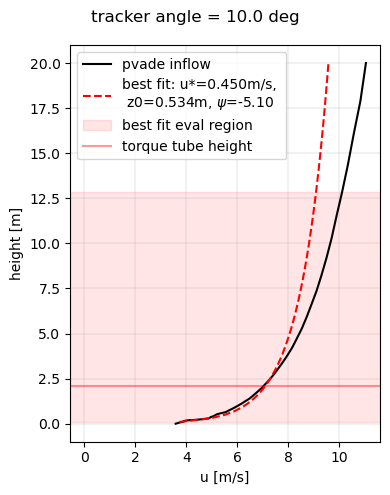

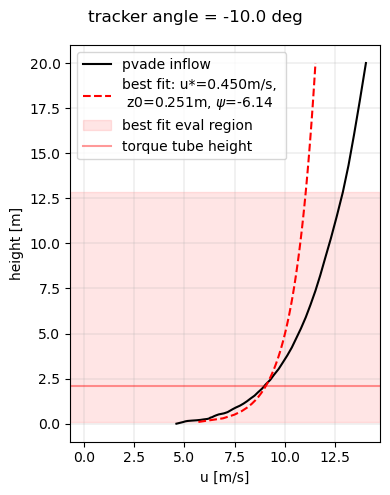

In [20]:
# plot inflow profile and derive best-fit parameters
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

# Define the log law function (neutral stability assumption for simplicity, ψ(z/L) = 0)
def log_law(z, u_star, z0, psi):
    d0 = 0.0
    kappa = 0.41
    u_star = 0.45
    # Guard against invalid log inputs
    valid = np.maximum((z - d0) / z0, 1e-9)
    return (u_star / kappa) * (np.log(valid) - psi)
    # return (u_star / kappa) * (np.log((z - d0) / z0) - psi)

for tilt in tilts:
    u_profile = np.nanmean(np.nanmean(readdata[tilt]['u'][:,0,:,:], axis=0), axis=0)
    interp_func = interp1d(zi, u_profile, kind='linear', fill_value='extrapolate')
    
    z_fit_max_idx = 45
    
    # Assign weights: Emphasize z = panel_height
    weights = np.ones_like(zi[1:z_fit_max_idx])
    weights[np.argmin(np.abs(zi - params[tilt]['panel_height']))] += 10  # Increase weight at z = 2.1
    
    # bounds=([u_star min, z0 min, psi min], [u_star max, z0 max, psi max])
    bounds=([0.3, 1e-5, -10],[0.7, 1, 1])
    
    # Initial guess (optional)
    p0 = [0.45, 1e-2, -3]
    
    # Fit the log law equation to the data
    popt, pcov = curve_fit(log_law, zi[1:z_fit_max_idx], u_profile[1:z_fit_max_idx], sigma=1/weights, bounds=bounds, p0=p0)
    u_star, z0, psi = popt
    
    # Print results
    print(f"Estimated u_star (friction velocity): {u_star:.3f} m/s")
    print(f"Estimated z0 (roughness length): {z0:.6f} m")
    print(f"Estimated psi (stability parameter): {psi:.2f} m")
    
    # for pvade inflow
    u_fit_h_panel = log_law(params[tilt]['panel_height'], u_star, z0, psi)
    u_pvade_h_panel = interp_func(params[tilt]['panel_height'])
    error_h_panel = (u_fit_h_panel - u_pvade_h_panel)/u_pvade_h_panel * 100
    print(f"u_mean at h_panel: {u_fit_h_panel:.3f} m/s")
    print(f"perc error of u_mean at h_panel: {error_h_panel:.2f}%")
    
    # Plot the results
    z_fit = np.linspace(min(zi[1:]), max(zi[1:]), 100)
    u_fit = log_law(z_fit, u_star, z0, psi)
    
    fig, axs = plt.subplots(figsize=[4,5])
    plt.suptitle(f'tracker angle = {tilt} deg')
    axs.plot(u_profile, zi, 'k', label='pvade inflow')
    axs.plot(u_fit, z_fit, 'r--', label=f'best fit: u*={u_star:.3f}m/s, \n z0={z0:.3f}m, $\\psi$={psi:.2f}')
    axs.axhspan(zi[1],zi[z_fit_max_idx], color='r', alpha=0.1, label='best fit eval region')
    axs.axhline(params[tilt]['panel_height'], color='r', alpha=0.4, label='torque tube height')
    axs.set_xlabel('u [m/s]')
    axs.set_ylabel('height [m]')
    axs.grid(lw=0.25)
    axs.legend()
    
    plt.tight_layout()

In [24]:
# velocity signal at sonic location
i = int(np.argmin(np.abs(xi - xloc)))
j = int(np.argmin(np.abs(yi - yloc)))
k = int(np.argmin(np.abs(zi - zloc)))
# print(f'sonic loc indices = {i, j, k}')

vel_data = {}
for tilt in tilts:
    # create dataframe from velocity data
    nt = np.shape(readdata[tilt]['u'])[0]
    time_xdmf = np.arange(params[tilt]['dt_xdmf'], params[tilt]['tf']+params[tilt]['dt_xdmf'], params[tilt]['dt_xdmf'])[0:nt] #np.linspace(dt_xdmf, tf, nt)

    vel_data[tilt] = pd.DataFrame(index=time_xdmf)
    for comp in ['u', 'v', 'w']:
        vel_data[tilt][comp+' (m/s)'] = readdata[tilt][comp][:,0,j,k]


In [25]:
# merge sim data
sim_data = {}
for tilt in tilts:
    sim_data[tilt] = {}
    sim_data[tilt] = pd.merge(loadsdata[tilt], vel_data[tilt], left_index=True, right_index=True, how='inner')
sim_data[tilt]

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-y,accel-x,accel-z,accel-magnitude,u (m/s),v (m/s),w (m/s)
0.012,1056.314469,81.106633,-2669.463141,0.467971,0.035932,-1.182631,7.518080,5.192830,-8.302615,152.420421,NaN,NaN,NaN
0.024,598.048290,15.207128,-799.517326,0.264949,0.006737,-0.354204,25.905680,19.743818,-41.164147,2755.409599,NaN,NaN,NaN
0.048,794.689624,9.549827,-2932.681535,0.352065,0.004231,-1.299243,-2.488076,8.550185,-42.500917,1885.624151,NaN,NaN,NaN
0.060,312.271643,10.252205,-339.675260,0.138343,0.004542,-0.150484,4.111659,-10.851683,58.809622,3593.236351,NaN,NaN,NaN
0.072,375.886025,11.679116,-899.398173,0.166526,0.005174,-0.398453,2.907660,-3.398838,-38.414137,1495.652510,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.724,198.163662,6.483155,-716.990558,0.087791,0.002872,-0.317643,0.024915,-0.102235,0.689412,0.486362,4.667479,1.167419,3.356230
29.736,206.104760,6.673659,-744.977677,0.091309,0.002957,-0.330042,0.042624,-0.112071,0.420127,0.190883,4.340408,1.389402,3.008567
29.748,190.206254,7.558280,-696.377923,0.084266,0.003348,-0.308511,0.020197,-0.238663,1.359823,1.906487,4.633940,1.149343,2.555073
29.760,191.957127,7.806190,-713.956411,0.085041,0.003458,-0.316299,0.005529,-0.332552,1.512079,2.397004,5.271834,1.259819,2.262725


In [26]:
# calculate lift and drag coeff
for tilt in tilts:
    sfc_area = params[tilt]['panel_span'] * params[tilt]['panel_chord']
    sim_data[tilt]['vel_mag (m/s)'] = (sim_data[tilt]['u (m/s)']**2 + sim_data[tilt]['v (m/s)']**2 + sim_data[tilt]['w (m/s)']**2)**0.5
    sim_data[tilt]['fx_nd_calc'] = (sim_data[tilt]['fx_0'])/(0.5*1*sim_data[tilt]['vel_mag (m/s)']**2*sfc_area)
    sim_data[tilt]['fz_nd_calc'] = (sim_data[tilt]['fz_0'])/(0.5*1*sim_data[tilt]['vel_mag (m/s)']**2*sfc_area)

### Step 3: read in measurement data from DuraMAT ###

In [28]:
# read in experimental data
def read_csv_data(raw_data):
    # read csv
    exp_data = raw_data
    
    # construct time index
    tmp = (exp_data.index[1]-exp_data.index[0])
    dt_sonic1 = round(tmp.total_seconds(), 3)
    tf_sonic1 = len(exp_data) * dt_sonic1 # final time [s]
    t_sonic1 = np.arange(0.0, tf_sonic1, dt_sonic1)

    exp_data['u (m/s)'] = -1.0*exp_data['u (m/s)'] # to make it positive from the west
    exp_data['Time'] = t_sonic1
    exp_data = exp_data.set_index('Time')

    return tf_sonic1, exp_data

exp_data = {}
for tilt in tilts:
    raw_exp_data = pd.read_csv(exp_data_fns[tilt], index_col='Time')
    raw_exp_data.index = pd.to_datetime(raw_exp_data.index)
    
    tf_sonic1, exp_data[tilt] = read_csv_data(raw_exp_data)
    # print(tf_sonic1)
    dt_exp = exp_data[tilt].index[1]-exp_data[tilt].index[0]
    # print(dt_exp)
    
    # cut sonic data to time period simulated
    if tilt == -40.0:
        tstart = 250.0
    elif tilt == 40.0:
        tstart = 0.0
    elif tilt == -10.0:
        tstart = 280.0
    elif tilt == 10.0:
        tstart = 100.0
    
    exp_data[tilt] = exp_data[tilt][exp_data[tilt].index >= tstart]
    exp_data[tilt] = exp_data[tilt][exp_data[tilt].index <= sim_data[tilt].index[-1]+tstart]
    exp_data[tilt].index = exp_data[tilt].index - tstart
    exp_data[tilt] = exp_data[tilt][exp_data[tilt].index > 0.0]

exp_data[tilt]

,3D wind speed (m/s),Wind direction (deg),u (m/s),v (m/s),w (m/s),temp (degC),Drive tracker angle (deg),Drive torque north (kNm),Panel defl mid (mm),Drag force (kN),Lift force (kN),Drag force tracker angle (kN),Lift force tracker angle (kN),AccNW X (g),AccNW Y (g),AccNE X (g),AccNE Y (g)
Time,,,,,,,,,,,,,,,,,
0.02,5.027459,286.77190,4.723211,1.423495,0.969685,3.977546,-10.136614,1.284942,-1.538869,0.270786,-1.535705,0.274447,-1.535055,0.053949,-0.001462,-1.002211,-0.160913
0.04,5.027534,286.77097,4.723286,1.423432,0.969803,3.976869,-10.135786,1.268850,-1.554774,0.267395,-1.516472,0.270988,-1.515834,0.008784,-0.010811,-1.009173,-0.154164
0.06,5.028424,286.77030,4.724413,1.423713,0.968510,3.977847,-10.137386,1.228600,-1.461210,0.258913,-1.468368,0.262433,-1.467743,0.036151,-0.005928,-1.036176,-0.158877
0.08,5.954063,286.49304,5.702218,1.688322,-0.291789,3.929387,-10.141635,1.203324,-1.430669,0.253586,-1.438158,0.257141,-1.437527,0.089781,-0.005448,-1.027582,-0.148714
0.10,5.955065,286.50818,5.702734,1.690113,-0.291798,3.930615,-10.136559,1.174960,-1.354200,0.247609,-1.404259,0.250955,-1.403665,0.021787,-0.003174,-0.996514,-0.159671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.70,6.384067,286.11124,6.133331,1.771599,0.000631,3.319238,-10.138269,1.189045,-1.540217,0.250577,-1.421094,0.254006,-1.420485,0.003716,-0.000210,-0.977276,-0.163643
29.72,6.383566,286.11234,6.132816,1.771577,0.000513,3.320292,-10.141194,1.221809,-1.554939,0.257482,-1.460251,0.261079,-1.459612,-0.005359,0.001542,-0.973891,-0.162659
29.74,6.383002,286.11664,6.132142,1.771879,0.000553,3.318612,-10.142132,1.246892,-1.554719,0.262768,-1.490229,0.266464,-1.489573,-0.046017,0.001471,-0.973689,-0.164701


In [29]:
# calculate lift and drag force coefficients
for tilt in tilts:
    exp_data[tilt]['Drag Coefficient'] = (exp_data[tilt]['Drag force (kN)']*1000)/(0.5*1*exp_data[tilt]['3D wind speed (m/s)']**2*sfc_area)
    exp_data[tilt]['Lift Coefficient'] = (exp_data[tilt]['Lift force (kN)']*1000)/(0.5*1*exp_data[tilt]['3D wind speed (m/s)']**2*sfc_area)

x, y, z =  [[ 1.22743410e+00  3.05384649e-01  8.93325740e+00]
 [ 1.60309720e+01  5.81846525e+00  4.39314710e+01]
 [ 1.46519162e+01 -8.52859657e-01  4.28204993e+01]
 ...
 [ 2.13293433e-01  1.95900076e-03  1.13154577e+00]
 [ 2.52249519e-01 -2.16562663e-02  1.22777139e+00]
 [ 1.92565145e-01 -1.62671551e-02  1.06803454e+00]]
x', y', z' =  [[-3.42457247e-01  3.05384649e-01  9.01068285e+00]
 [ 8.15880568e+00  5.81846525e+00  4.60478024e+01]
 [ 6.99361905e+00 -8.52859657e-01  4.47142382e+01]
 ...
 [ 1.35621650e-02  1.95900076e-03  1.15139306e+00]
 [ 3.52170176e-02 -2.16562663e-02  1.25292145e+00]
 [ 4.17739499e-03 -1.62671551e-02  1.08524729e+00]]


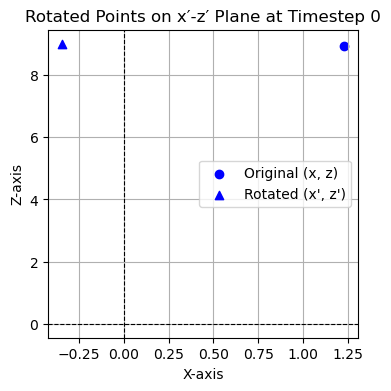

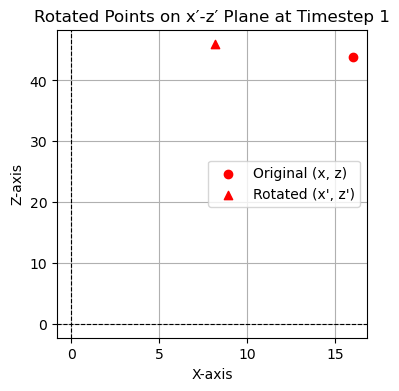

x, y, z =  [[ 5.19283033e+00  7.51807960e+00 -8.30261483e+00]
 [ 1.97438181e+01  2.59056797e+01 -4.11641470e+01]
 [ 8.55018454e+00 -2.48807601e+00 -4.25009173e+01]
 ...
 [-2.38662849e-01  2.01970396e-02  1.35982310e+00]
 [-3.32552407e-01  5.52909998e-03  1.51207882e+00]
 [-2.69487569e-01  2.80690707e-03  1.54902828e+00]]
x', y', z' =  [[ 3.67220563e+00  7.51807960e+00 -9.07820498e+00]
 [ 1.22957861e+01  2.59056797e+01 -4.39672492e+01]
 [ 1.04008118e+00 -2.48807601e+00 -4.33399568e+01]
 ...
 [ 1.09377854e-03  2.01970396e-02  1.38060770e+00]
 [-6.49304560e-02  5.52909998e-03  1.54685407e+00]
 [ 3.59248999e-03  2.80690707e-03  1.57229108e+00]]


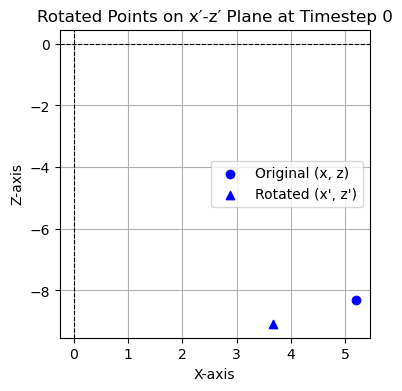

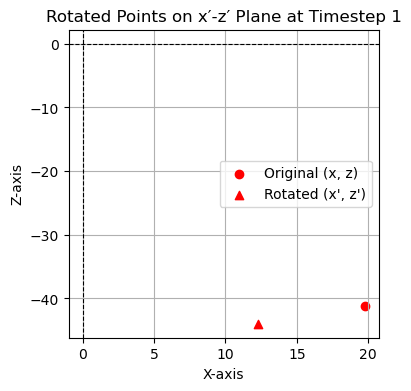

In [31]:
# convert accelerations from pvade coordinate system to that of experimental data
from scipy.spatial.transform import Rotation as R

# testdata = sim_data.copy()
# testdata = testdata[testdata.index > 2.0]

for tilt in tilts:

    tracker_angle = -tilt
    
    # Make acceleration table shape=(num_steps, 3)
    # for testing
    # pvade_accel = np.full((2, 3), np.nan)
    # pvade_accel[:, 0] = [0.86, -0.56] #, 0.02] # testdata['accel-x']
    # pvade_accel[:, 1] = [0.07, -0.036] #, -0.028] # testdata['accel-y']
    # pvade_accel[:, 2] = [3.92, -2.307] #, -0.072] # testdata['accel-z']
    
    # real data
    pvade_accel = np.full((np.shape(sim_data[tilt])[0], 3), np.nan)
    pvade_accel[:, 0] = sim_data[tilt]['accel-x']
    pvade_accel[:, 1] = sim_data[tilt]['accel-y']
    pvade_accel[:, 2] = sim_data[tilt]['accel-z']
    
    # Make a rotation matrix about the y-axis
    Ry = R.from_euler("y", tracker_angle, degrees=True).as_matrix()
    
    # Apply the rotation matrix to our simulation data
    # Now it should match the experimental setup with the mapping:
    # our x' = their y
    # our y' = their z
    # our z' = their x
    rotated_accel = np.dot(pvade_accel, Ry.T)
    
    print('x, y, z = ', pvade_accel)
    print('x\', y\', z\' = ', rotated_accel)
    
    # Names for axes
    original_axes = ["x", "y", "z"]
    rotated_axes = ["x'", "y'", "z'"]
    
    # Choose a timestep to visualize (e.g., the first one):
    # timestep = 0  # Change this index to visualize other timesteps
    colors = ['blue', 'red', 'green']
    
    for timestep in range(2):
        plt.figure(figsize=(4, 4))
        # Extract rotated x' and z' at the chosen timestep
        x_prime = rotated_accel[timestep, 0]  # x' corresponds to column 0
        z_prime = rotated_accel[timestep, 2]  # z' corresponds to column 2
        
        # Extract original x and z for comparison (optional)
        x_original = pvade_accel[timestep, 0]
        z_original = pvade_accel[timestep, 2]
        
        # Scatter all points at the given timestep
        plt.scatter(pvade_accel[timestep, 0], pvade_accel[timestep, 2], color=colors[timestep], label="Original (x, z)", marker="o")
        plt.scatter(rotated_accel[timestep, 0], rotated_accel[timestep, 2], color=colors[timestep], label="Rotated (x', z')", marker="^")
        plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
        plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
        plt.xlabel("X-axis")
        plt.ylabel("Z-axis")
        plt.title(f"Rotated Points on x′-z′ Plane at Timestep {timestep}")
        plt.legend()
        plt.grid()
    plt.show()

    # assign calculated values to new columns in dataframe
    for n,comp in enumerate(['x','y','z']):
        sim_data[tilt][f'accel-{comp}-prime'] = rotated_accel[:,n]
    
        # reverse sign of z' accelerations to match DuraMAT sign convention
        # (our z' = their x, and positive x accelerations are towards the ground)
        if comp == 'z':
            sim_data[tilt][f'accel-{comp}-prime'] = -rotated_accel[:,n]
    
# sim_data[tilt][f'accel-x-prime']
    
    # Plot because it needs som pizazz, also, checking
    # fig, ax = plt.subplots(3, 1, figsize=(4, 10))
    # for idx in range(3):
    #     ax[idx].plot(testdata.index, pvade_accel[:, idx], "-", color=f"C{idx}", label="PVade")
    #     ax[idx].plot(testdata.index, experimental_accel[:, idx], ".", color=f"C{idx}", label="Experimental")
    #     ax[idx].set_ylabel(f"{['x', 'y', 'z'][idx]}-Acceleration")
    #     ax[idx].set_xlim([5, 10])
    
    # plt.legend()
    # plt.show()

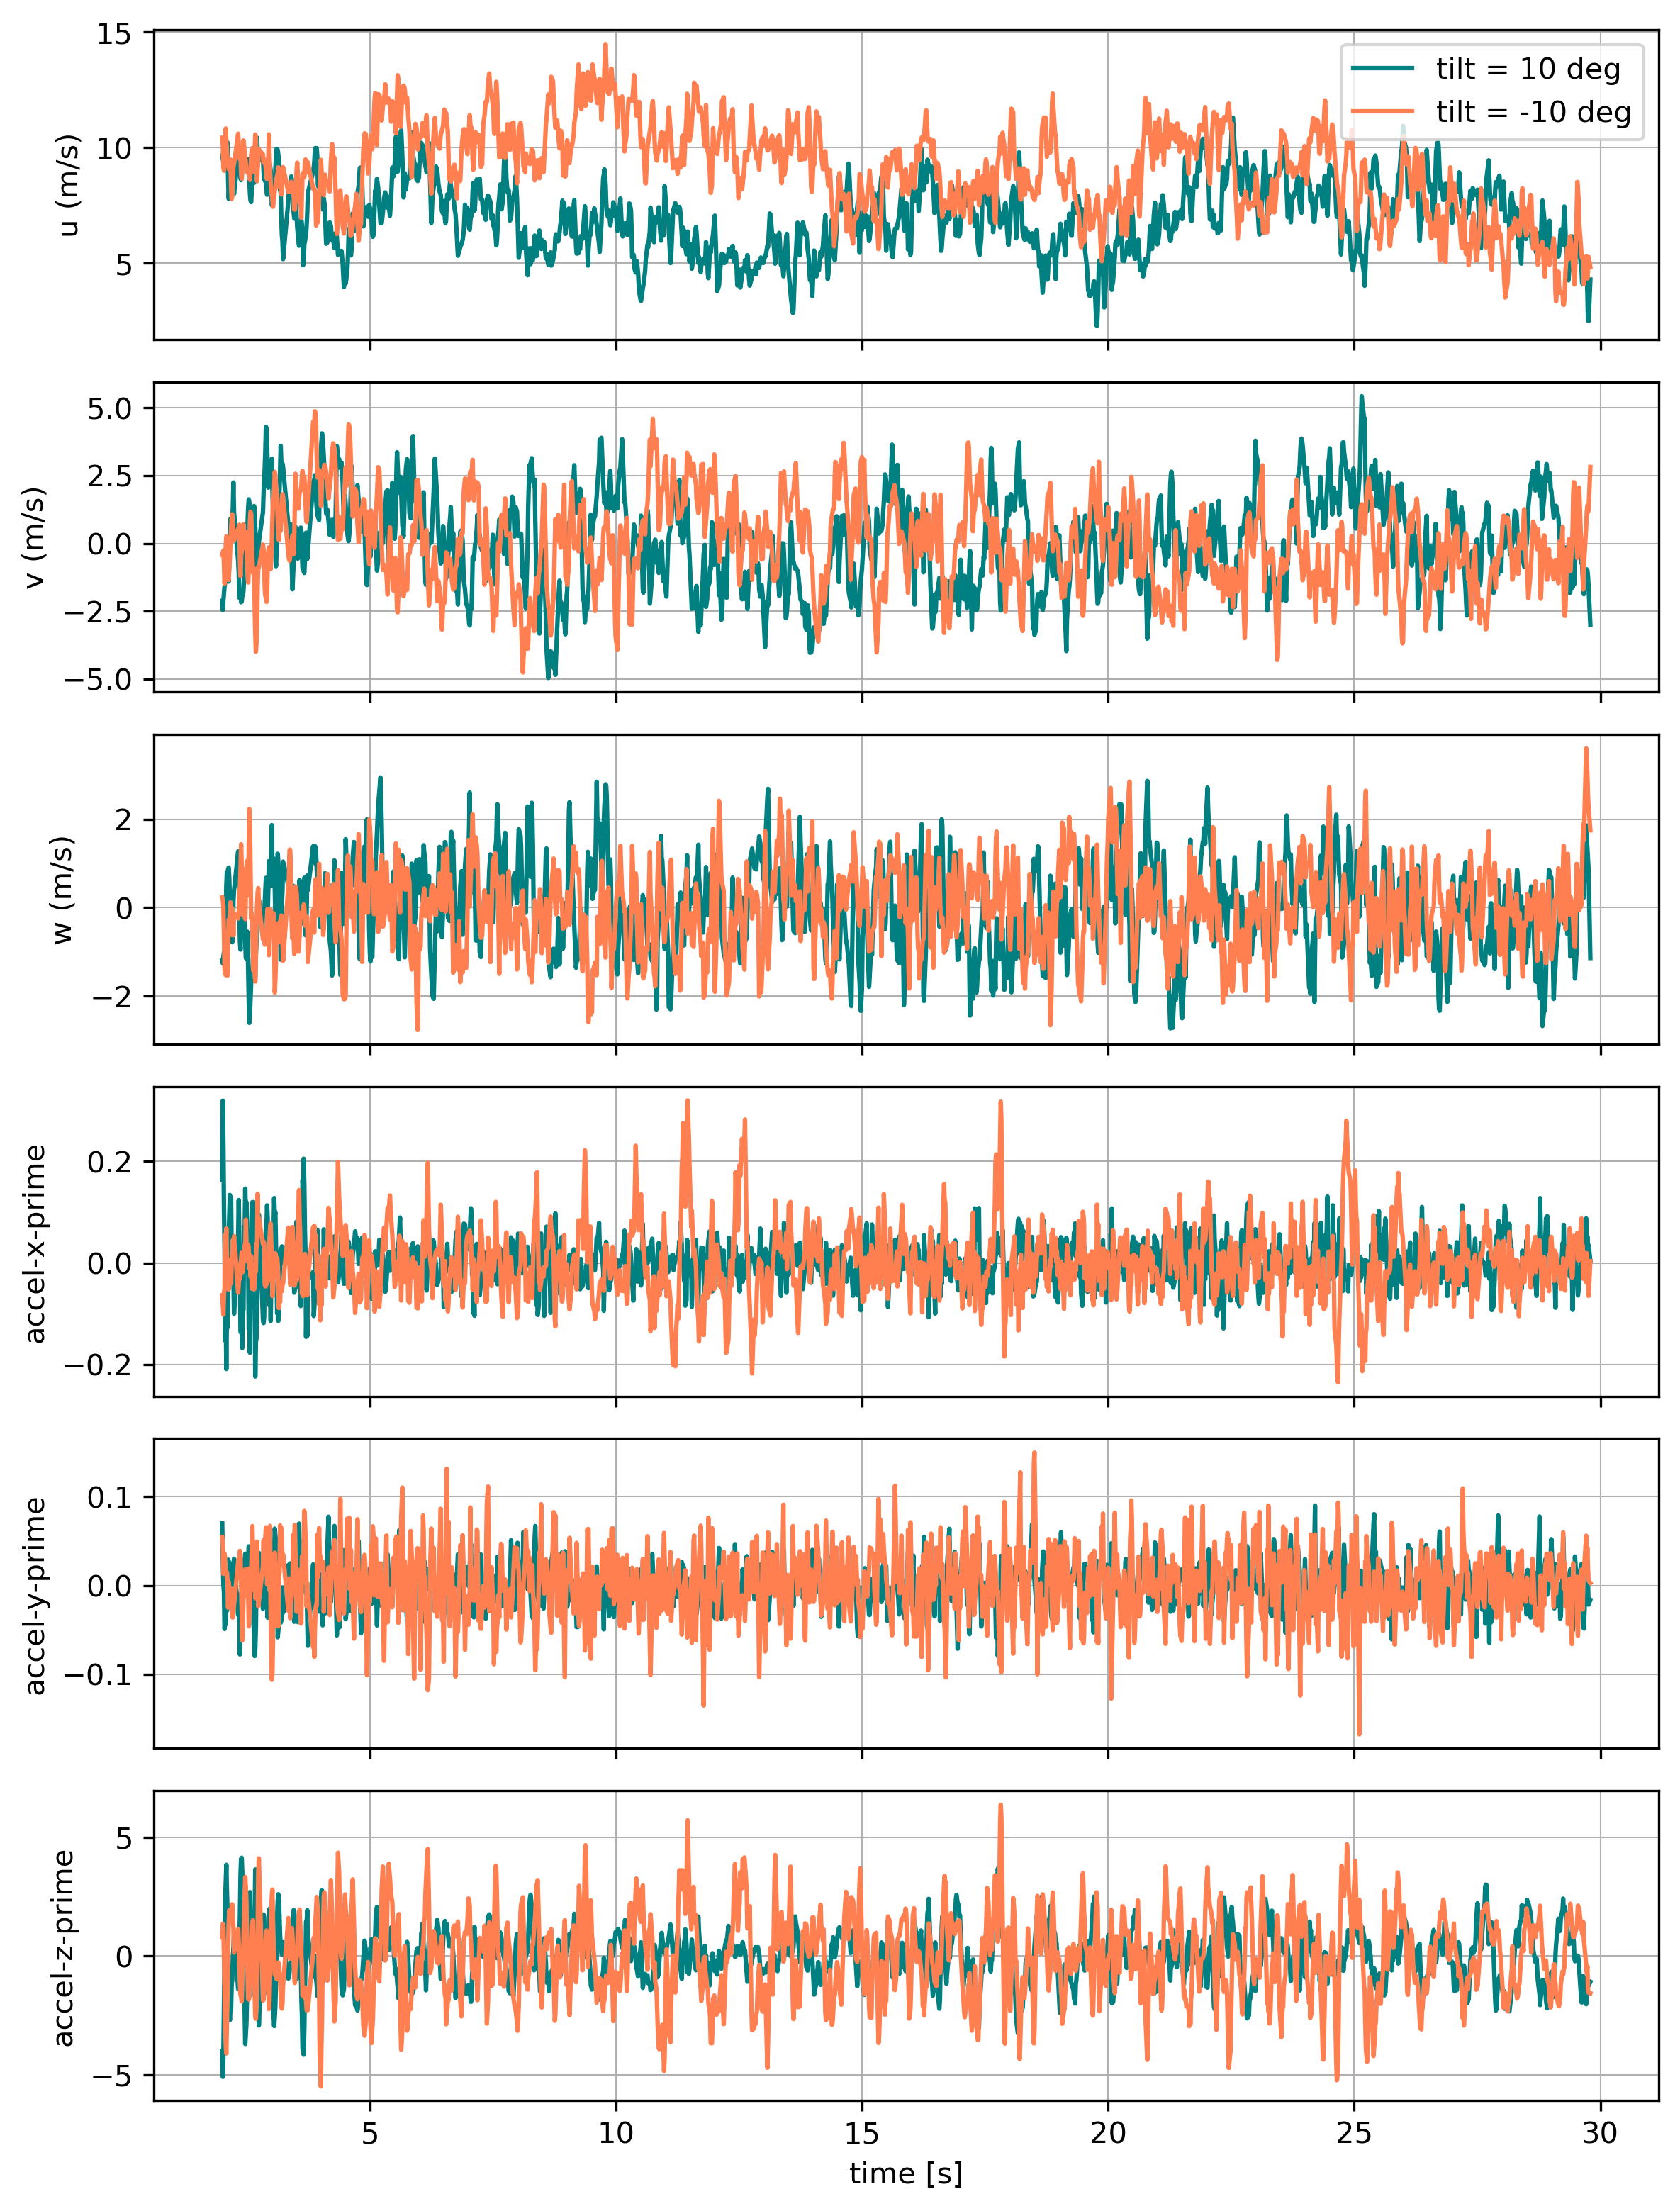

In [75]:
# plot accelerations from simulations
comps = ['u (m/s)','v (m/s)','w (m/s)', 'accel-x-prime', 'accel-y-prime', 'accel-z-prime']

colors_tilts = {10.0:'teal',40.0:'darkorange',-10.0:'coral',-40.0:'navajowhite'}

fig, axs = plt.subplots(len(comps),1, figsize=[8,len(comps)*1.75], sharex=True, dpi=300)
# plt.suptitle(f'tracker angle = {tilt} deg')
for tilt in tilts:
    for comp,ax in zip(comps, axs.ravel()):
        pltdata = sim_data[tilt][comp][sim_data[tilt][comp].index > 2.0]
        # pltdata = sim_data[comp][(sim_data[comp].index > 2.0) & (sim_data[comp].index < 5.0)]
        ax.plot(pltdata, color=colors_tilts[tilt], label=f'tilt = {int(tilt)} deg')
        ax.set_ylabel(f"{comp}")
        ax.grid(lw=0.5)
axs[-1].set_xlabel("time [s]")
axs[0].legend()
plt.tight_layout()

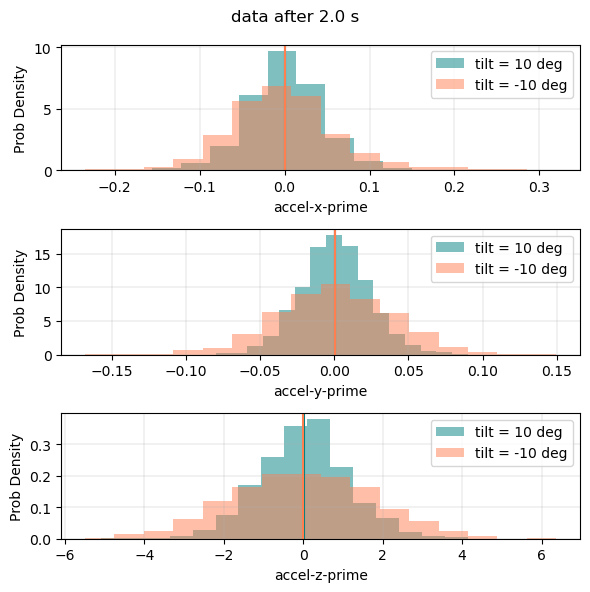

In [76]:
# histograms
time_threshold = 2.0

comps = ['accel-x-prime', 'accel-y-prime', 'accel-z-prime']
nbins = 16

# for k,angle in enumerate(float_list_to_str_list(tracker_angles0)):
fig, axs = plt.subplots(len(comps),1,figsize=[6,6]) #, sharex=True) #, dpi=300) #, sharey=True)
plt.suptitle(f'data after {time_threshold} s')
# for j,u in enumerate(float_list_to_str_list(u_refs0)):


for tilt in tilts:
    statistics_list = []
    
    for comp,ax in zip(comps, axs.ravel()):
            pltdata = sim_data[tilt][comp][sim_data[tilt][comp].index > time_threshold]
            
            ax.hist(pltdata, bins=nbins, density=True, alpha=0.5, label=f'tilt = {int(tilt)} deg', color=colors_tilts[tilt])
            ax.axvline(np.mean(pltdata.values), color=colors_tilts[tilt], label='')
            ax.set_xlabel(comp)
            ax.legend()
    
    for ax in axs.ravel():
        ax.grid(lw=0.25)
        ax.legend()
        ax.set_ylabel('Prob Density')
    
    # # for ax in axs:
    # axs[-1].set_xlabel('time [s]')

plt.tight_layout()

In [51]:
# interpolate to 50 Hz to match duramat loads signals
interp_sim_data = {}
for tilt in tilts:
    new_time_index = exp_data[tilt].index #exp_data[exp_data.index>0.0].index
    interp_sim_data[tilt] = pd.DataFrame(index=new_time_index)
    for col in sim_data[tilt].columns:
        interpolator = interp1d(sim_data[tilt].index, sim_data[tilt][col].values, kind='linear')  # Use 'linear' or 'cubic' as needed
        interp_sim_data[tilt][col] = interpolator(new_time_index)
    
interp_sim_data[tilt]

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-y,accel-x,accel-z,accel-magnitude,u (m/s),v (m/s),w (m/s),vel_mag (m/s),fx_nd_calc,fz_nd_calc,accel-x-prime,accel-y-prime,accel-z-prime
Time,,,,,,,,,,,,,,,,,,,
0.02,750.803683,37.173630,-1422.832598,0.332623,0.016469,-0.630346,19.776480,14.893489,-30.210303,1887.746539,NaN,NaN,NaN,NaN,NaN,NaN,9.421259,19.776480,32.337568
0.04,729.142512,11.435594,-2221.626799,0.323026,0.005066,-0.984230,6.976509,12.281396,-42.055327,2175.552633,NaN,NaN,NaN,NaN,NaN,NaN,4.791983,6.976509,43.549054
0.06,312.271643,10.252205,-339.675260,0.138343,0.004542,-0.150484,4.111659,-10.851683,58.809622,3593.236351,NaN,NaN,NaN,NaN,NaN,NaN,-0.474638,4.111659,-59.800546
0.08,399.212505,11.170598,-1104.896676,0.176860,0.004949,-0.489494,0.695796,-1.662011,10.285991,1298.853683,NaN,NaN,NaN,NaN,NaN,NaN,0.149382,0.695796,-10.418328
0.10,160.038253,9.774249,58.839721,0.070900,0.004330,0.026067,1.069417,4.173178,-13.802079,217.879512,NaN,NaN,NaN,NaN,NaN,NaN,1.713072,1.069417,14.317059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.70,191.792829,5.811701,-703.303223,0.084968,0.002575,-0.311579,0.045668,-0.042262,0.103869,0.233649,4.999296,0.256468,3.080861,5.941690,0.220302,-0.808847,-0.023584,0.045668,-0.109629
29.72,195.861369,6.451697,-711.322485,0.086771,0.002858,-0.315132,0.035286,-0.102792,0.581847,0.373714,4.878968,0.987295,3.437629,6.057305,0.200661,-0.728422,-0.000194,0.035286,-0.590857
29.74,200.805258,6.968533,-728.777759,0.088961,0.003087,-0.322865,0.035148,-0.154268,0.733359,0.762751,4.438252,1.309383,2.857402,5.445594,0.252666,-0.917037,-0.024578,0.035148,-0.749006


In [52]:
# merge dataframes
alldata = {}

for tilt in tilts:
    alldata[tilt] = {}

    alldata[tilt]['exp'] = exp_data[tilt].copy()
    alldata[tilt]['sim'] = sim_data[tilt].copy()
    alldata[tilt]['sim_interp'] = interp_sim_data[tilt].copy()
    
    # adjustments
    alldata[tilt]['exp'] = alldata[tilt]['exp'].rename(columns={'3D wind speed (m/s)':'vel_mag (m/s)'})
    
    for comp in ['fx','fy','fz']:
        alldata[tilt]['sim'][comp+'_0'] = alldata[tilt]['sim'][comp+'_0']/1000
        alldata[tilt]['sim_interp'][comp+'_0'] = alldata[tilt]['sim_interp'][comp+'_0']/1000
    
    for key in ['sim','sim_interp']:
        alldata[tilt][key] = alldata[tilt][key].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)',
                                                   'fx_nd_calc':'Drag Coefficient','fz_nd_calc':'Lift Coefficient', 
                                                    'accel-x-prime':'AccNW Y (g)', 'accel-z-prime':'AccNW X (g)'})
        # alldata['sim'] = alldata['sim'].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)'})
        # alldata['sim_interp'] = alldata['sim_interp'].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)'})

alldata[tilt]['sim']

,Drag force (kN),Lateral force (kN),Lift force (kN),fx_nd_0,fy_nd_0,fz_nd_0,accel-y,accel-x,accel-z,accel-magnitude,u (m/s),v (m/s),w (m/s),vel_mag (m/s),Drag Coefficient,Lift Coefficient,AccNW Y (g),accel-y-prime,AccNW X (g)
0.012,1.056314,0.081107,-2.669463,0.467971,0.035932,-1.182631,7.518080,5.192830,-8.302615,152.420421,NaN,NaN,NaN,NaN,NaN,NaN,3.672206,7.518080,9.078205
0.024,0.598048,0.015207,-0.799517,0.264949,0.006737,-0.354204,25.905680,19.743818,-41.164147,2755.409599,NaN,NaN,NaN,NaN,NaN,NaN,12.295786,25.905680,43.967249
0.048,0.794690,0.009550,-2.932682,0.352065,0.004231,-1.299243,-2.488076,8.550185,-42.500917,1885.624151,NaN,NaN,NaN,NaN,NaN,NaN,1.040081,-2.488076,43.339957
0.060,0.312272,0.010252,-0.339675,0.138343,0.004542,-0.150484,4.111659,-10.851683,58.809622,3593.236351,NaN,NaN,NaN,NaN,NaN,NaN,-0.474638,4.111659,-59.800546
0.072,0.375886,0.011679,-0.899398,0.166526,0.005174,-0.398453,2.907660,-3.398838,-38.414137,1495.652510,NaN,NaN,NaN,NaN,NaN,NaN,-10.017747,2.907660,37.240338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.724,0.198164,0.006483,-0.716991,0.087791,0.002872,-0.317643,0.024915,-0.102235,0.689412,0.486362,4.667479,1.167419,3.356230,5.866218,0.214921,-0.777620,0.019034,0.024915,-0.696691
29.736,0.206105,0.006674,-0.744978,0.091309,0.002957,-0.330042,0.042624,-0.112071,0.420127,0.190883,4.340408,1.389402,3.008567,5.460865,0.257950,-0.932376,-0.037414,0.042624,-0.433205
29.748,0.190206,0.007558,-0.696378,0.084266,0.003348,-0.308511,0.020197,-0.238663,1.359823,1.906487,4.633940,1.149343,2.555073,5.415052,0.242097,-0.886360,0.001094,0.020197,-1.380608
29.760,0.191957,0.007806,-0.713956,0.085041,0.003458,-0.316299,0.005529,-0.332552,1.512079,2.397004,5.271834,1.259819,2.262725,5.873611,0.207666,-0.772382,-0.064930,0.005529,-1.546854


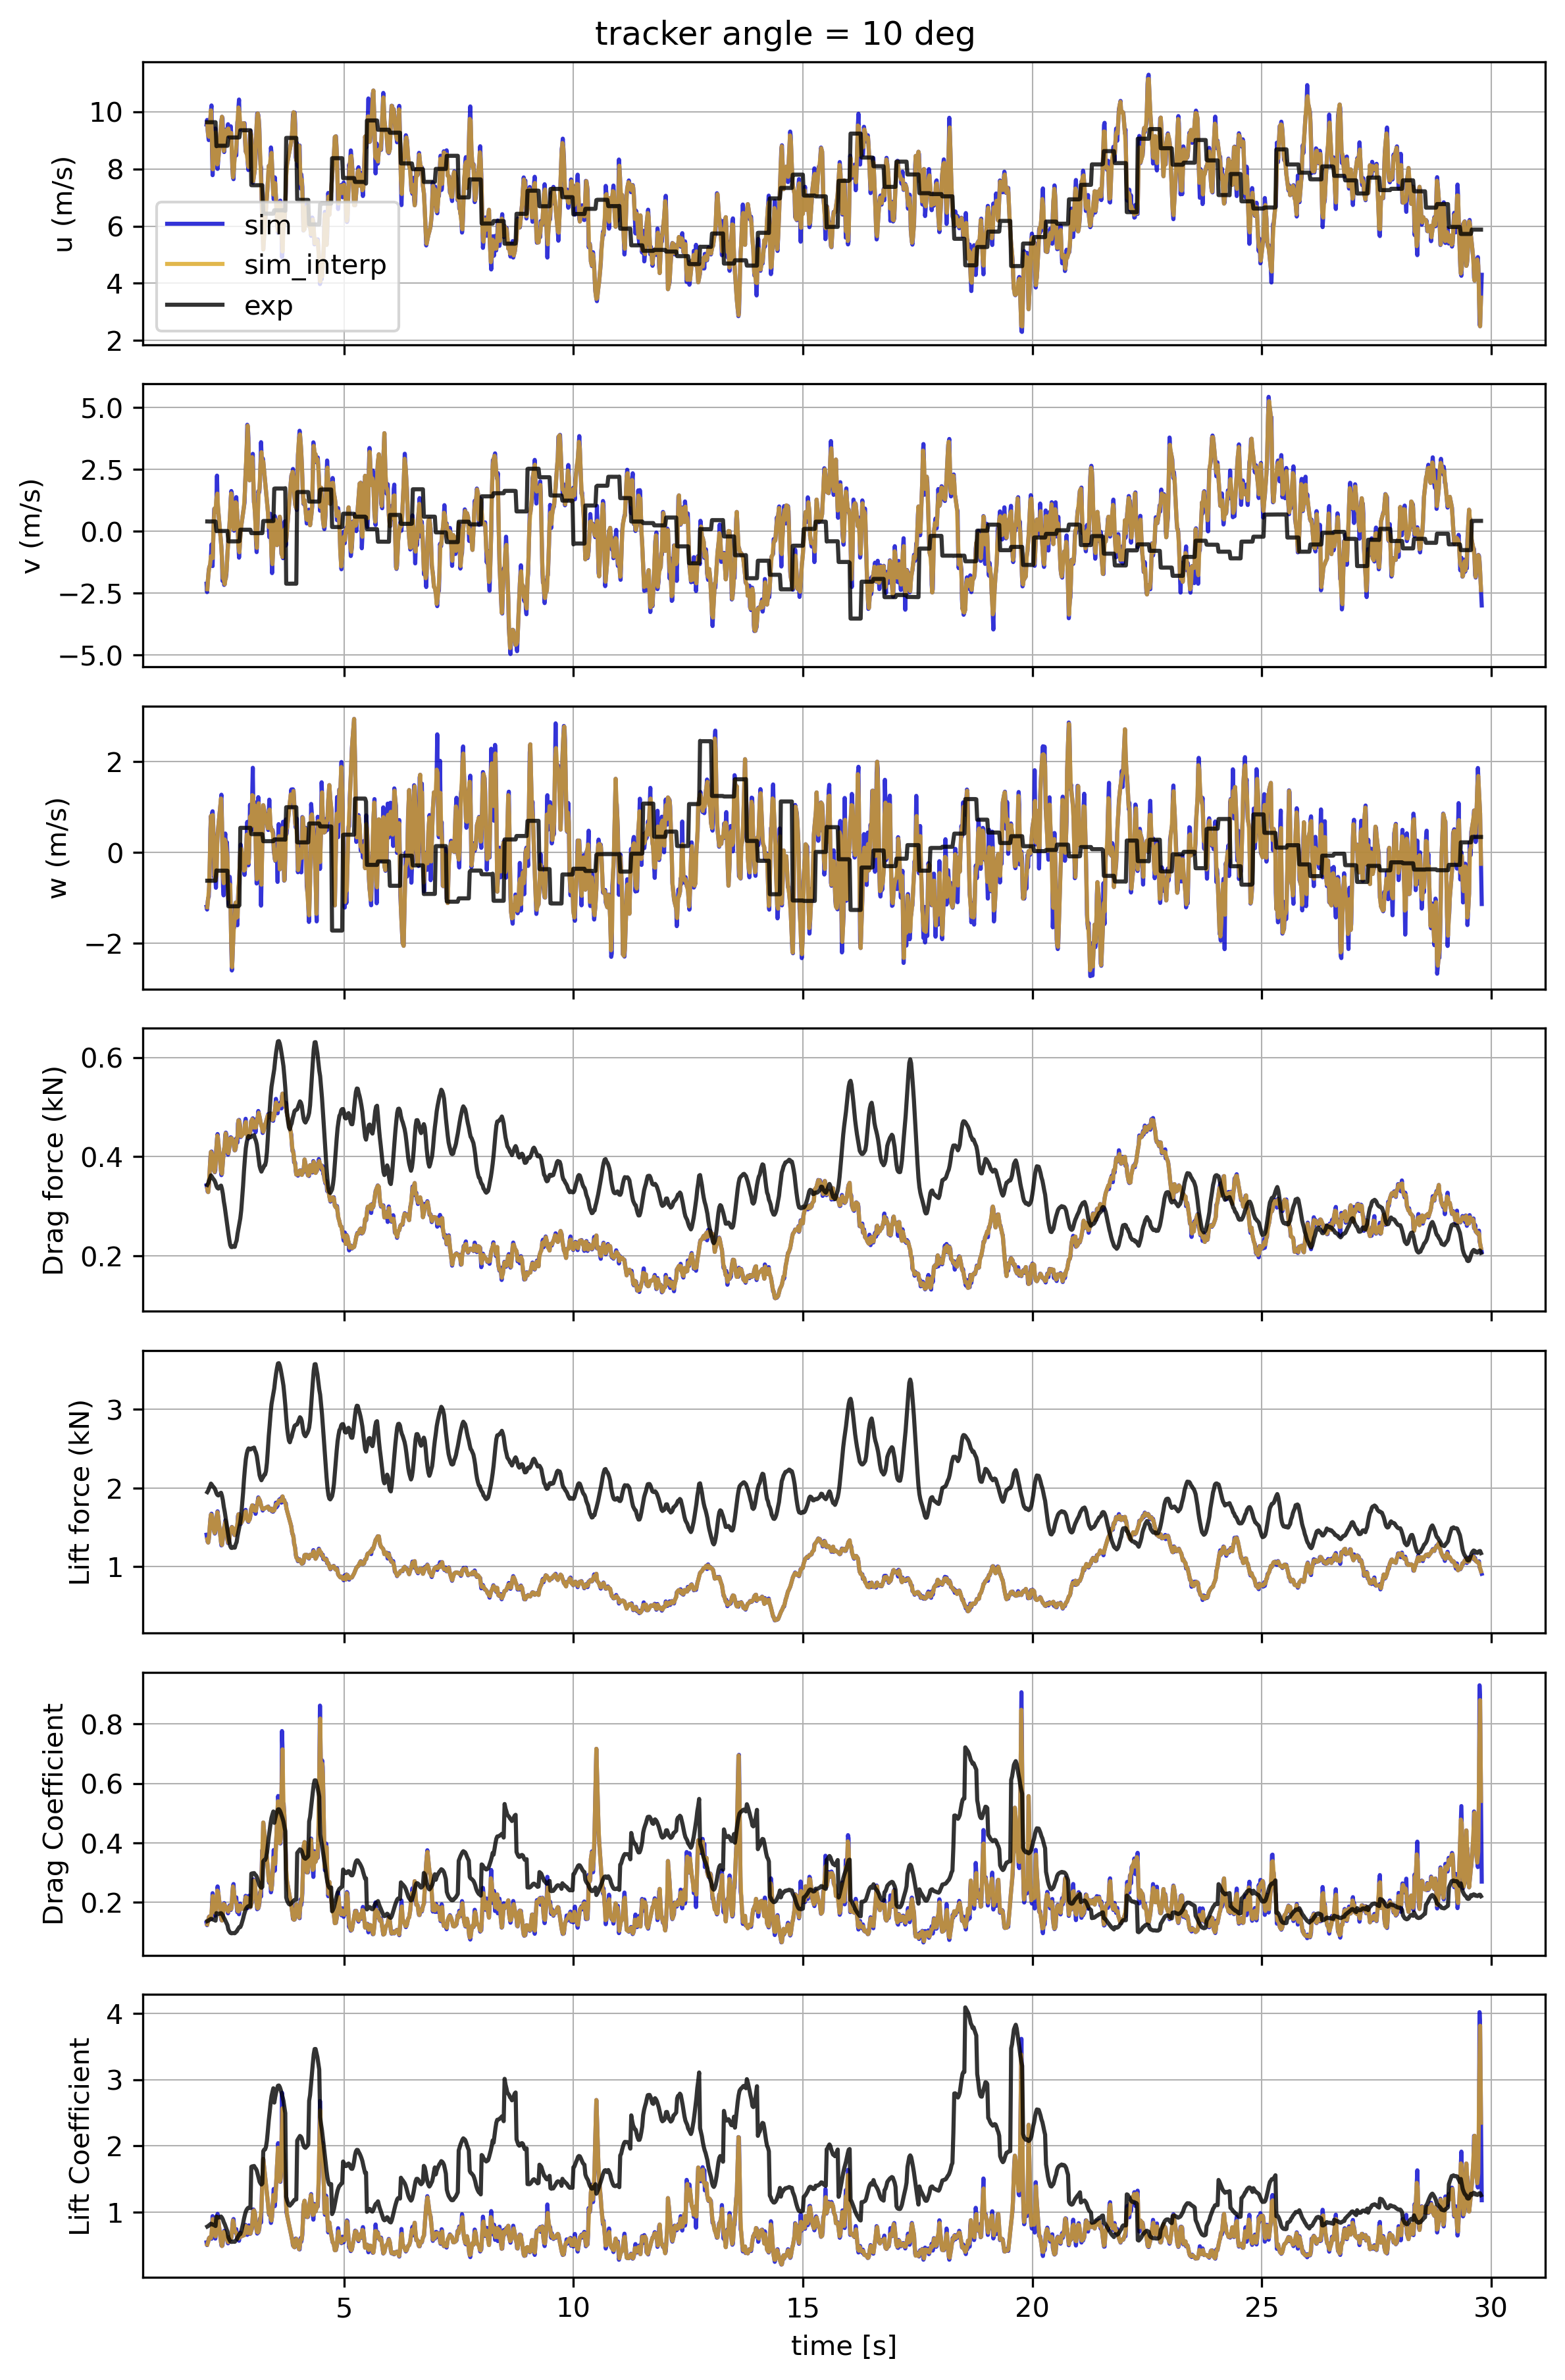

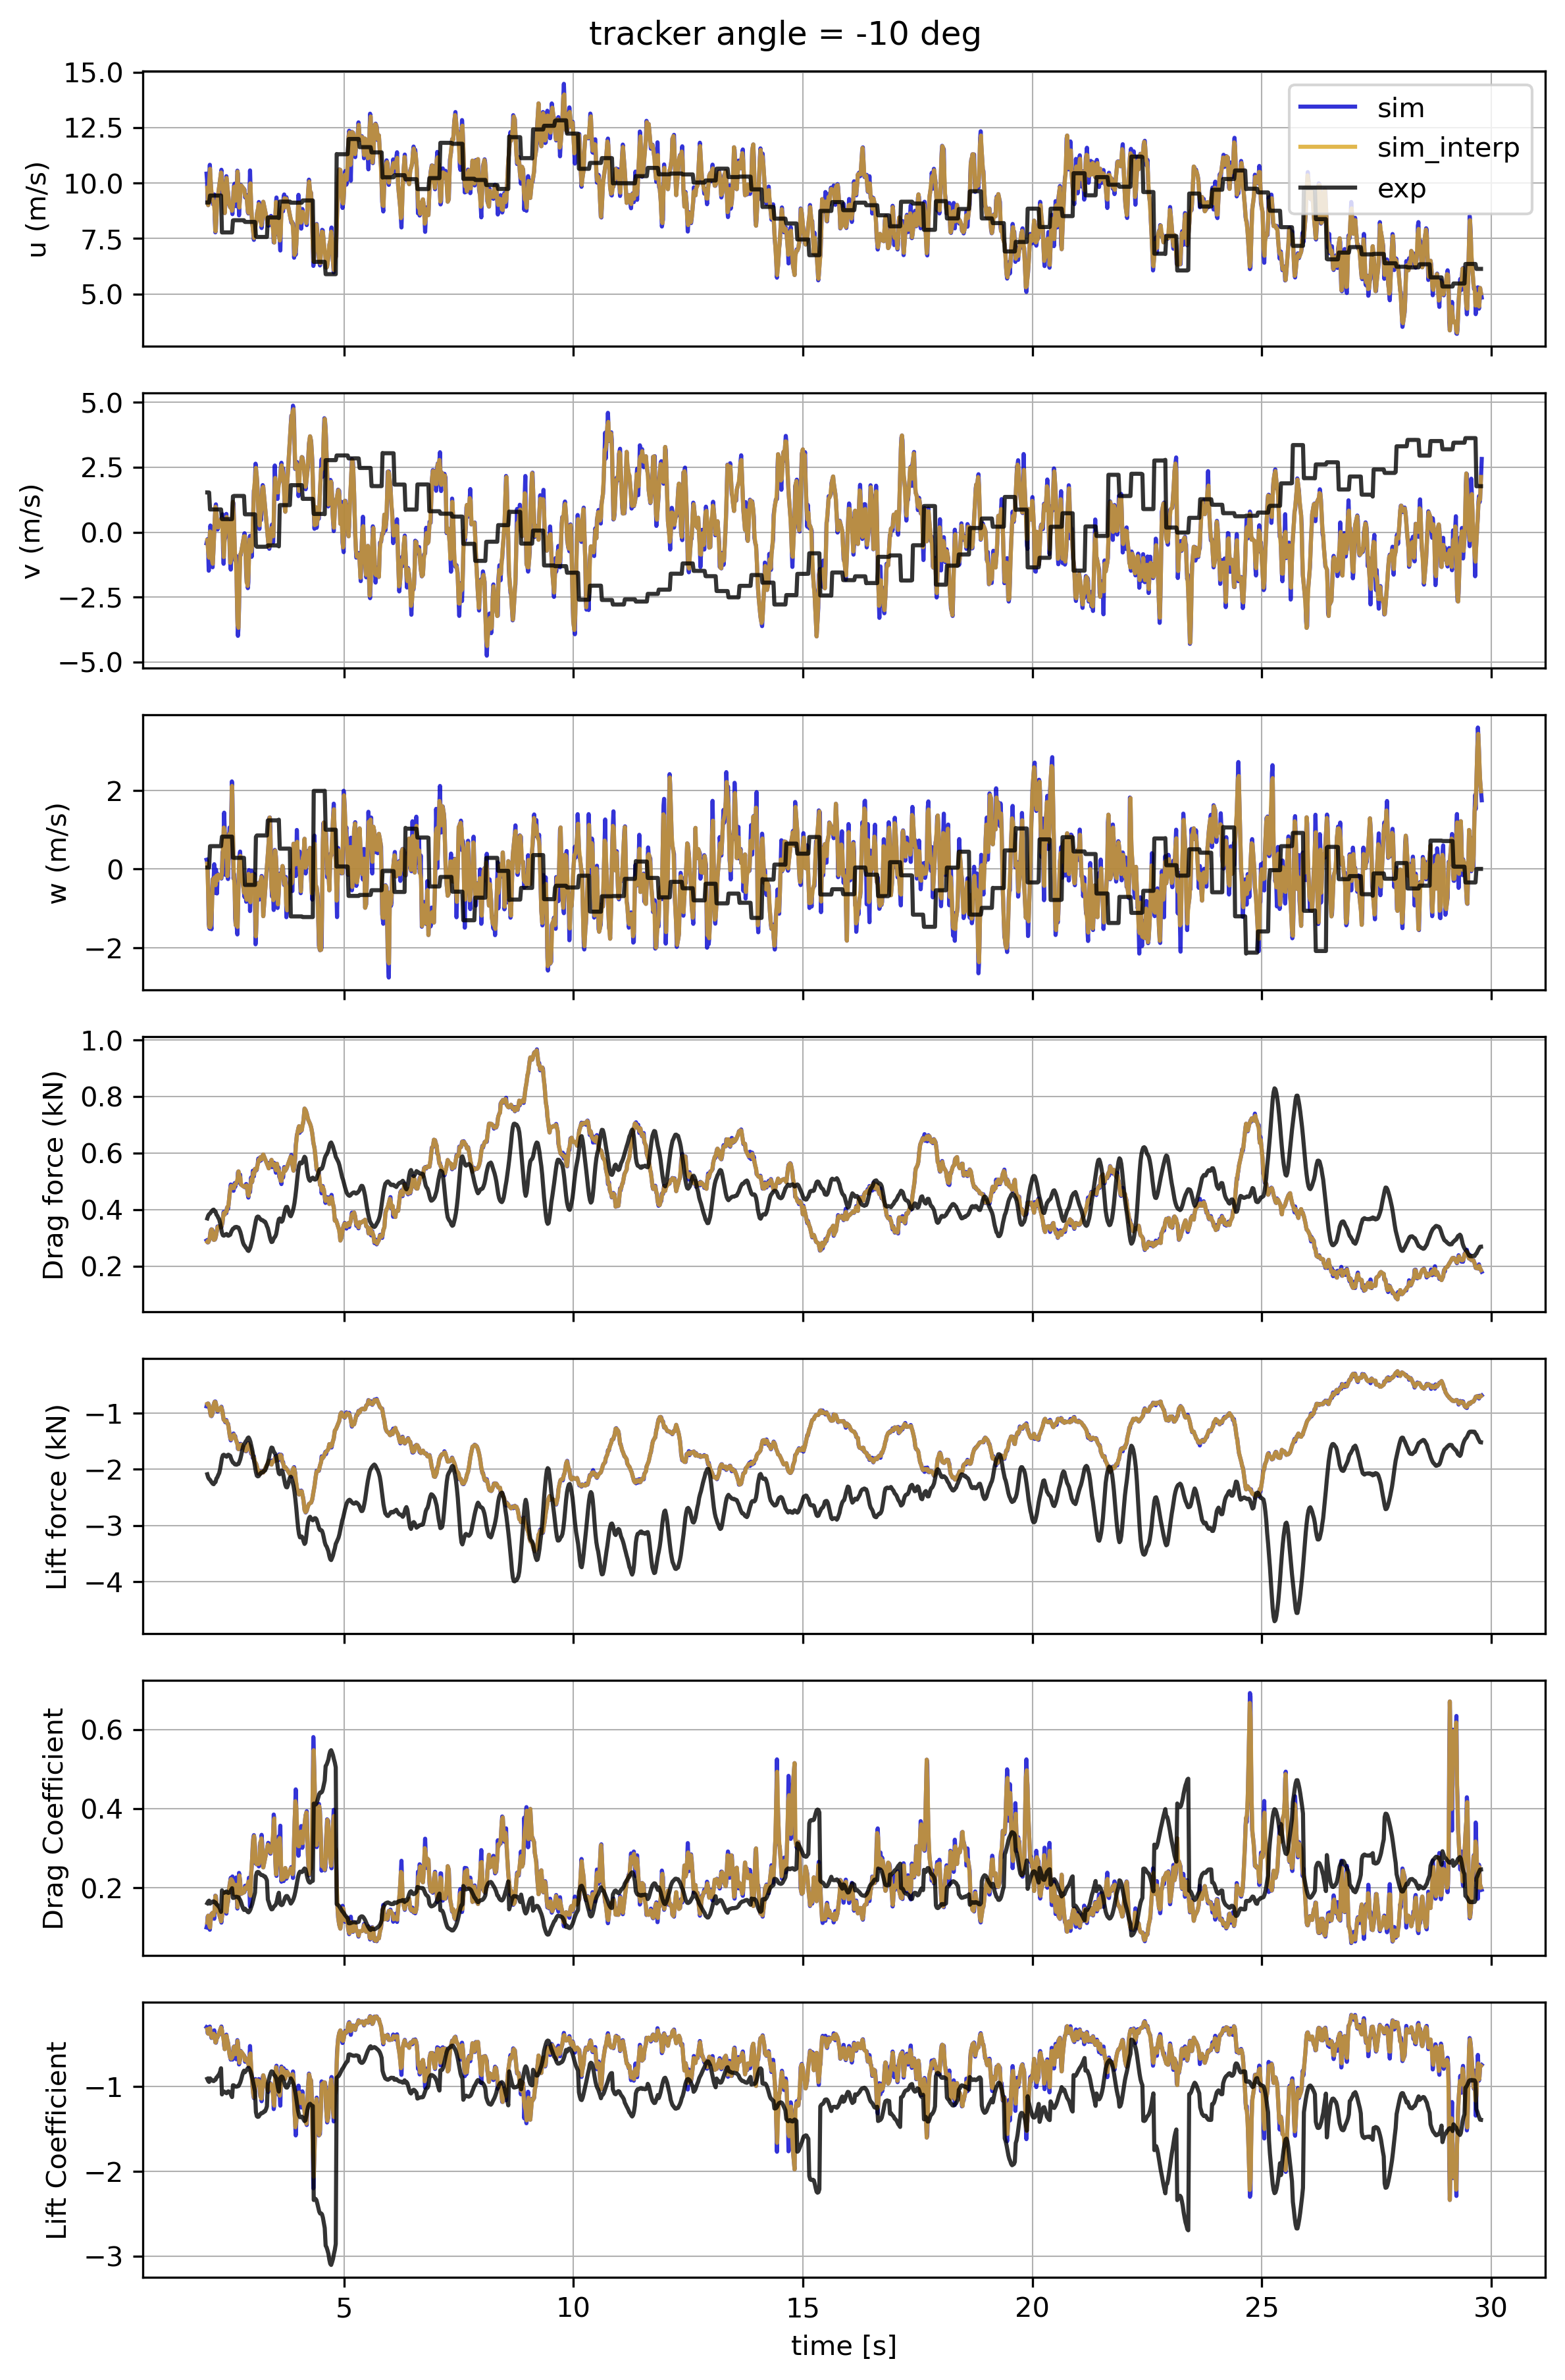

In [54]:
# plot velocity signals and drag and lift force
colors = {'exp': 'k', 'sim': 'mediumblue', 'sim_interp': 'goldenrod'}

comps = ['u (m/s)','v (m/s)','w (m/s)','Drag force (kN)', 'Lift force (kN)','Drag Coefficient', 'Lift Coefficient']
vars = ['sim','sim_interp','exp']
# vars = ['exp']

for tilt in tilts:
    fig, axs = plt.subplots(len(comps),1, figsize=[8,len(comps)*1.75], sharex=True, dpi=300)
    plt.suptitle(f'tracker angle = {int(tilt)} deg')
    
    for comp,ax in zip(comps, axs.ravel()):
        for var in vars:
            pltdata = alldata[tilt][var][comp][alldata[tilt][var][comp].index > 2.0]
            ax.plot(pltdata, label=var, alpha=0.8, color=colors[var])
            ax.set_ylabel(f"{comp}")
        ax.grid(lw=0.5)
    axs[0].legend()
    axs[-1].set_xlabel("time [s]")
    plt.tight_layout()

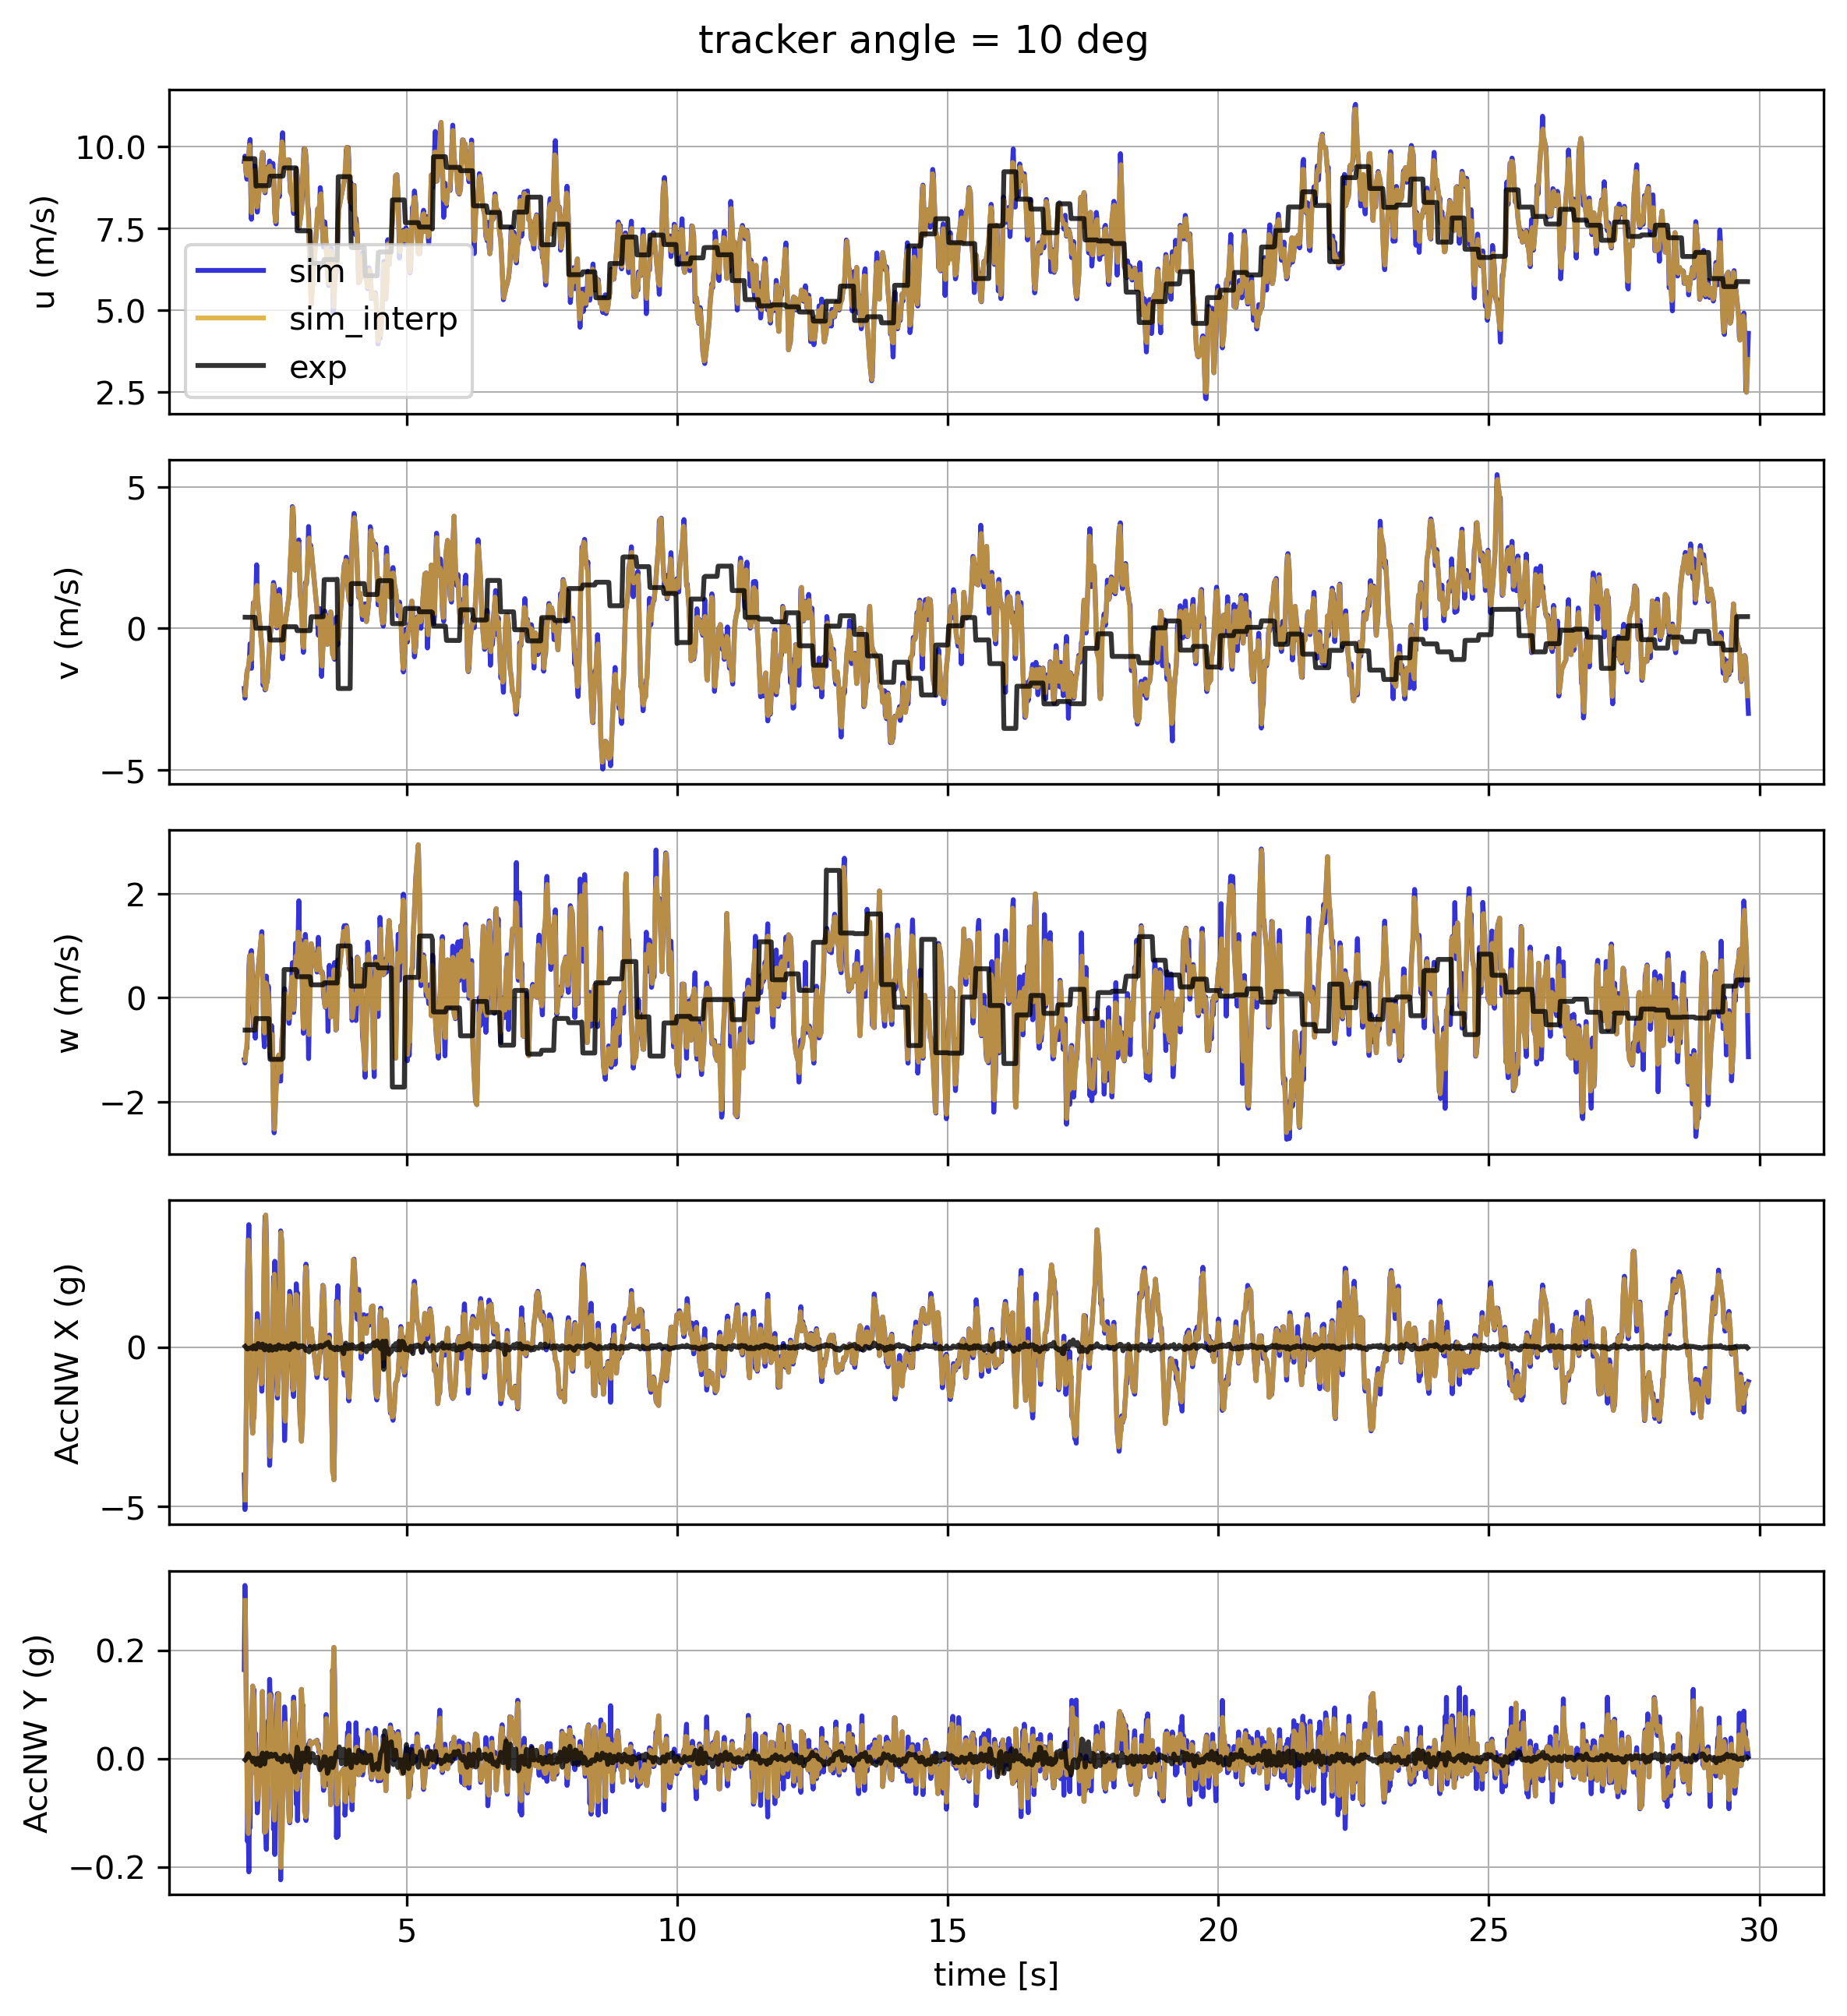

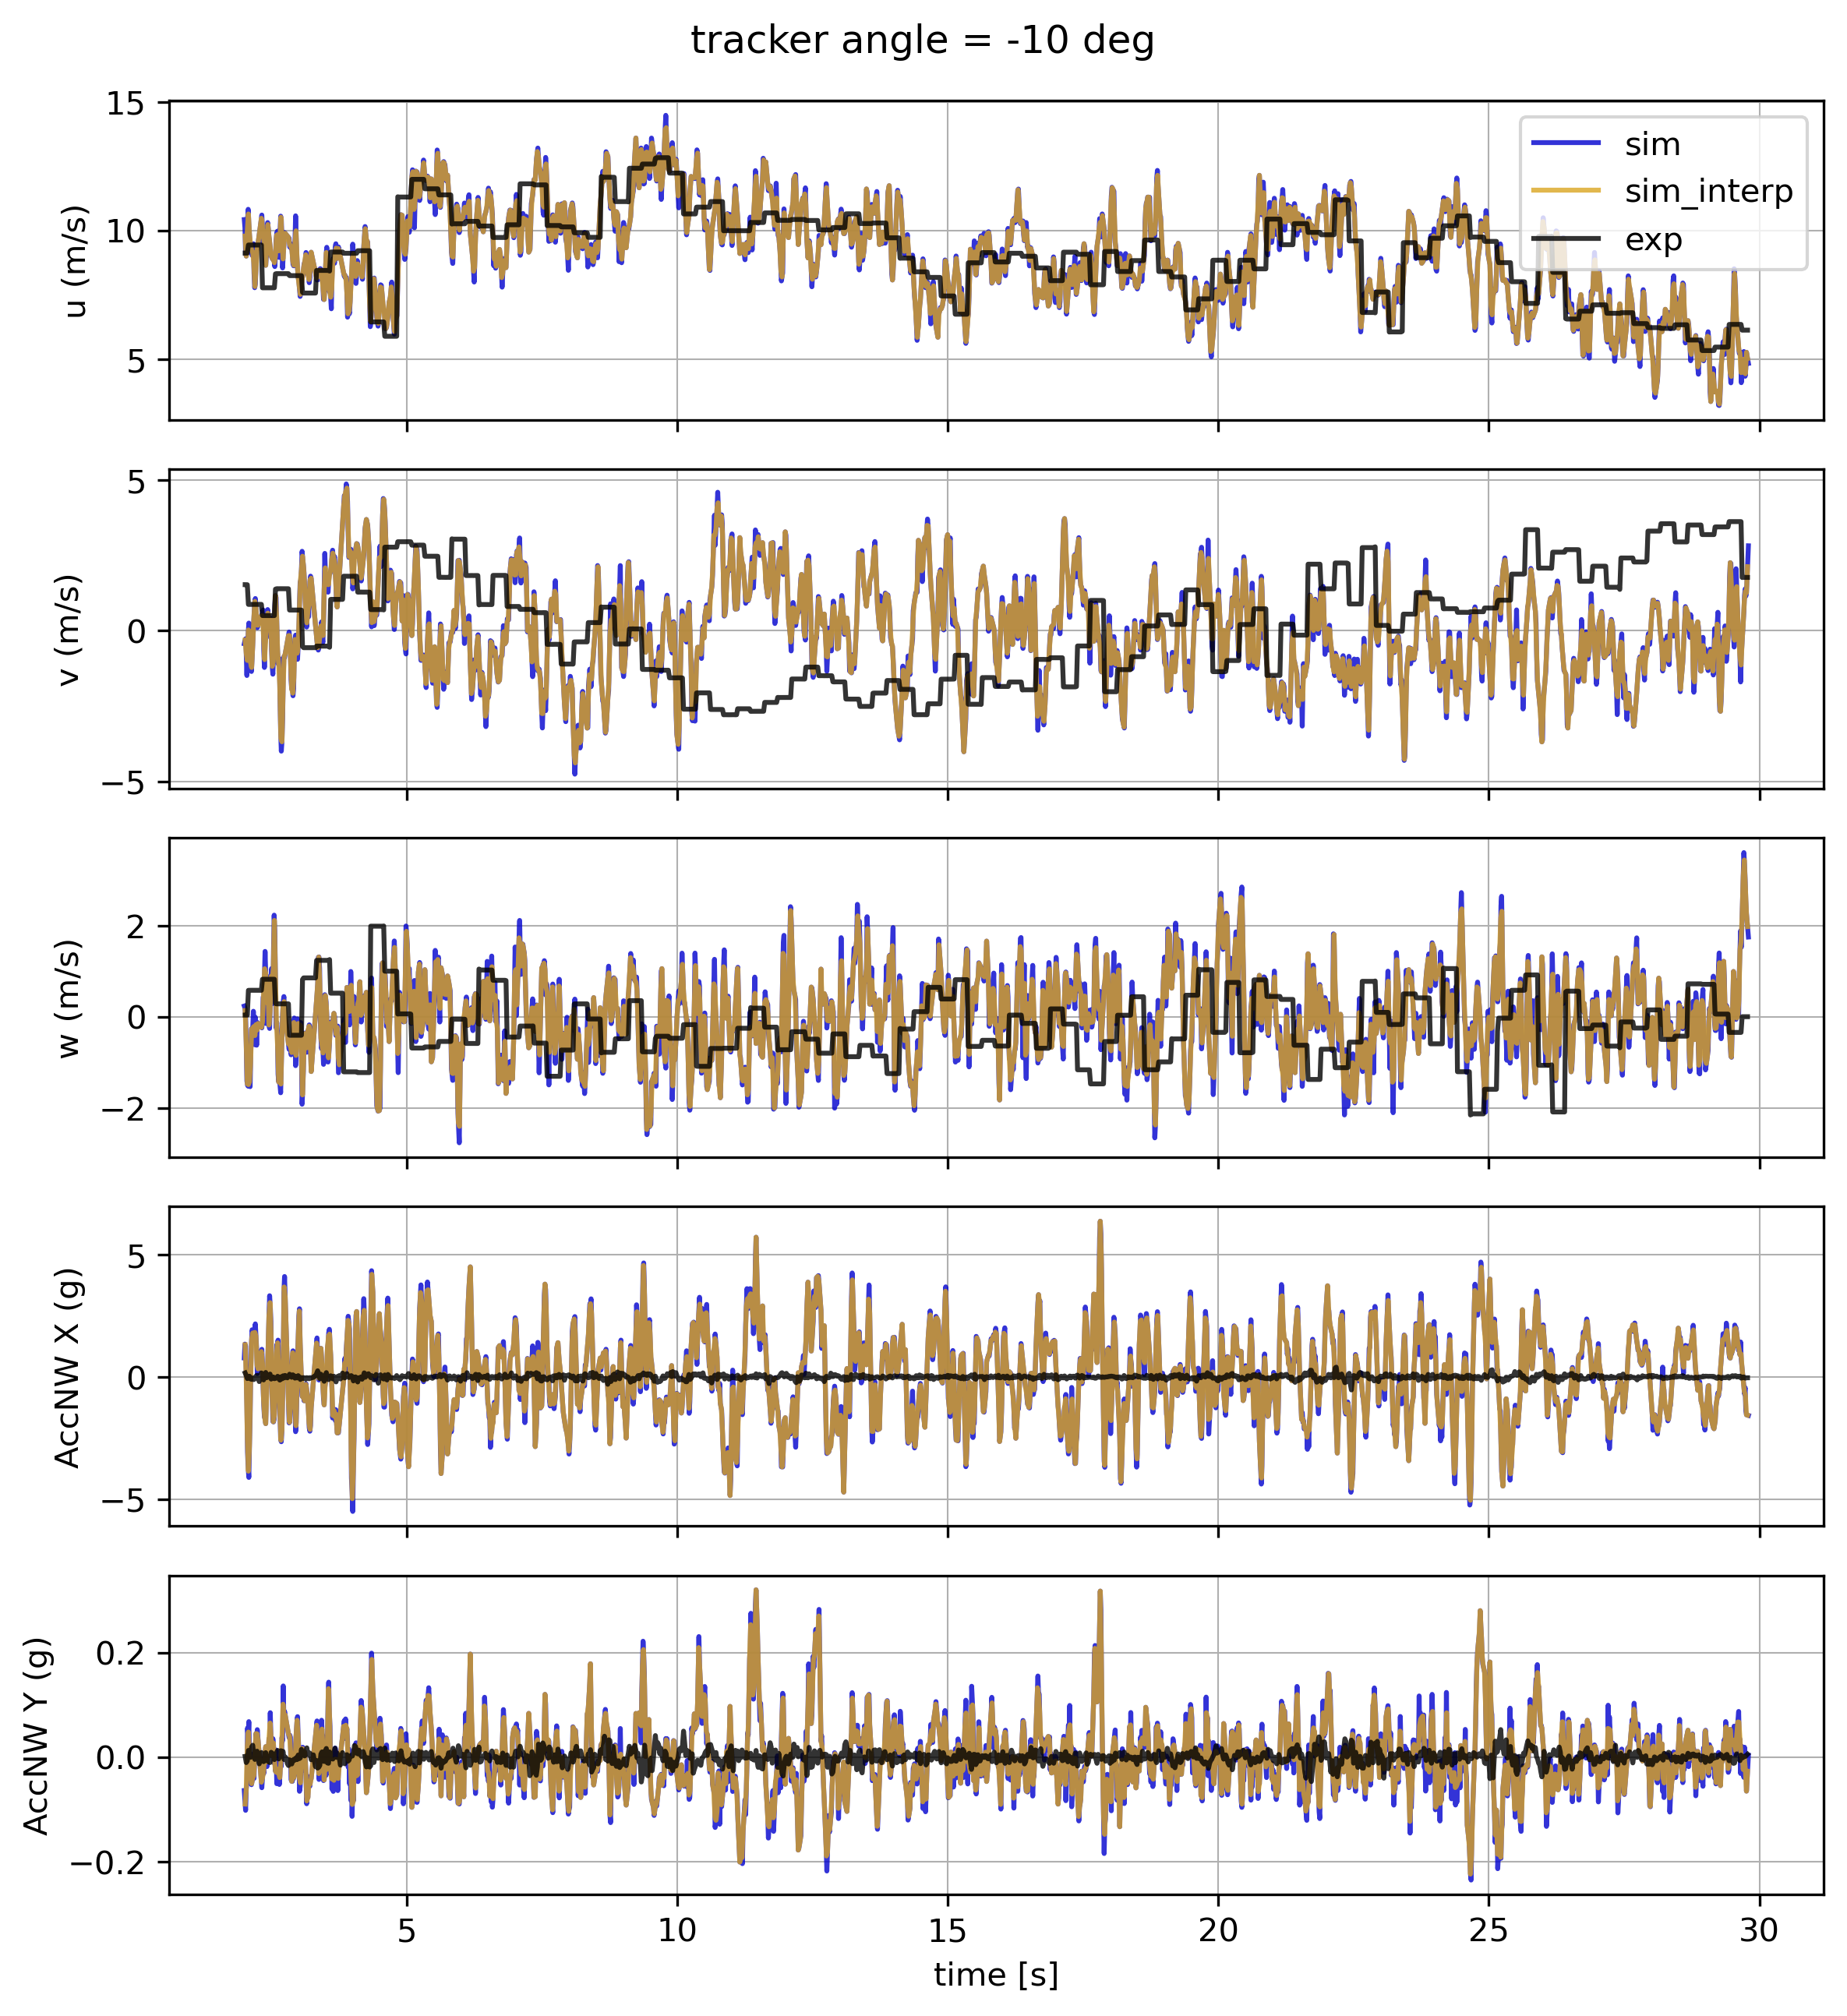

In [58]:
# plot velocity signals and accelerations
colors = {'exp': 'k', 'sim': 'mediumblue', 'sim_interp': 'goldenrod'}

comps = ['u (m/s)','v (m/s)','w (m/s)','AccNW X (g)','AccNW Y (g)']
# comps = ['u (m/s)','v (m/s)','w (m/s)','AccNW X (g)','AccNW Y (g)', 'AccNE X (g)','AccNE Y (g)']

# vars = ['exp']
vars = ['sim','sim_interp','exp']
# vars = ['sim']
# vars = ['exp']
# vars = ['exp']

for tilt in tilts:
    fig, axs = plt.subplots(len(comps),1, figsize=[8,len(comps)*1.75], sharex=True, dpi=300)
    plt.suptitle(f'tracker angle = {int(tilt)} deg')
    
    for comp,ax in zip(comps, axs.ravel()):
        for var in vars:
            pltdata = alldata[tilt][var][comp][alldata[tilt][var][comp].index > 2.0]
            # pltdata = alldata[var][comp][(alldata[var][comp].index > 2.0) & (alldata[var][comp].index < 5.0)]
            ax.plot(pltdata, label=var, alpha=0.8, color=colors[var])
            ax.set_ylabel(f"{comp}")
        ax.grid(lw=0.5)
    axs[0].legend()
    axs[-1].set_xlabel("time [s]")
    plt.tight_layout()

In [64]:
# compute errors
keys = ['sim_interp']
comps = ['u (m/s)','v (m/s)','w (m/s)','vel_mag (m/s)','Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient']
baseline = 'exp'

error_df = {}
error_list = []

for tilt in tilts:
    mean_abs_err = {}
    mean_perc_err = {}
    for key in keys:
        mean_abs_err[key] = {}
        mean_perc_err[key] = {}
        for comp in comps:
            mean_abs_err[key][comp] = round(float(np.nanmean(alldata[tilt][key][comp].values - alldata[tilt][baseline][comp].values)),4)
            mean_perc_err[key][comp] = 100*round(float(np.nanmean((alldata[tilt][key][comp].values - alldata[tilt][baseline][comp].values)/alldata[tilt][baseline][comp].values)),3)
    
            # Append results as a dictionary to the error list
            error_list.append({
                'Tilt': tilt,
                'Variable': comp,
                'Mean_Absolute_Error': mean_abs_err[key][comp],
                'Mean_Percent_Error [%]': mean_perc_err[key][comp]
            })
    
        error_df[key] = pd.DataFrame(error_list).set_index('Variable')
error_df[key]

,Tilt,Mean_Absolute_Error,Mean_Percent_Error [%]
Variable,,,
u (m/s),10.0,-0.1022,-1.2
v (m/s),10.0,0.2547,-140.6
w (m/s),10.0,0.0047,-16.3
vel_mag (m/s),10.0,0.0479,1.1
Drag force (kN),10.0,-0.0744,-16.2
Lift force (kN),10.0,-0.9743,-46.7
Drag Coefficient,10.0,-0.0679,-14.3
Lift Coefficient,10.0,-0.7965,-45.0
u (m/s),-10.0,-0.0591,-0.5


In [ ]:
# plot errors vs tracker angle

In [63]:
# compute stats
time_threshold = 2.0

vars_for_stats = ['u (m/s)', 'v (m/s)', 'w (m/s)', 
        'Drag force (kN)', 'Lift force (kN)', 
        'Drag Coefficient', 'Lift Coefficient']
nbins = 25

statistics_list = []
for tilt in tilts:
    for var in vars_for_stats:
        for key in alldata[tilt].keys():
            pltdata = alldata[tilt][key][var][alldata[tilt][key][var].index > time_threshold]
            
            stats = {
                'Key': f"{key}",
                'Tilt': f"{tilt}",
                'Var': f"{var}",
                'Mean': np.nanmean(pltdata.values),
                'Median': np.nanmedian(pltdata.values),
                'Max': np.max(pltdata.values),
                'Min': np.min(pltdata.values),
                'Std Dev': np.std(pltdata.values)
            }
            statistics_list.append(stats)
    
statistics_df = pd.DataFrame(statistics_list).set_index('Key')
statistics_df.round(3)

,Tilt,Var,Mean,Median,Max,Min,Std Dev
Key,,,,,,,
exp,10.0,u (m/s),7.089,7.123,9.699,4.599,1.273
sim,10.0,u (m/s),7.053,7.076,11.299,2.298,1.544
sim_interp,10.0,u (m/s),6.990,7.027,11.150,2.491,1.509
exp,10.0,v (m/s),-0.201,-0.222,2.526,-3.530,1.110
sim,10.0,v (m/s),0.063,0.094,5.430,-4.963,1.645
sim_interp,10.0,v (m/s),0.062,0.089,5.257,-4.724,1.611
exp,10.0,w (m/s),-0.001,-0.029,2.458,-1.723,0.645
sim,10.0,w (m/s),-0.022,-0.032,2.942,-2.727,0.973
sim_interp,10.0,w (m/s),-0.008,-0.015,2.942,-2.597,0.932


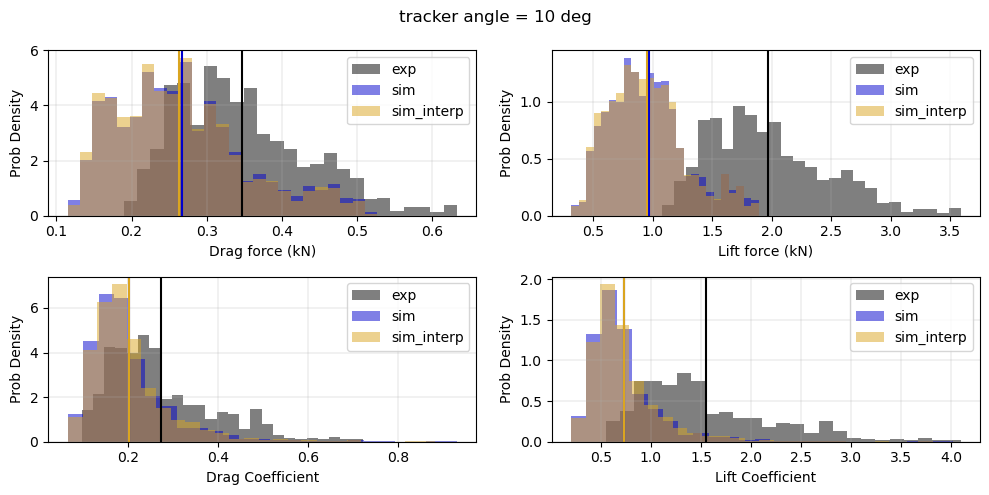

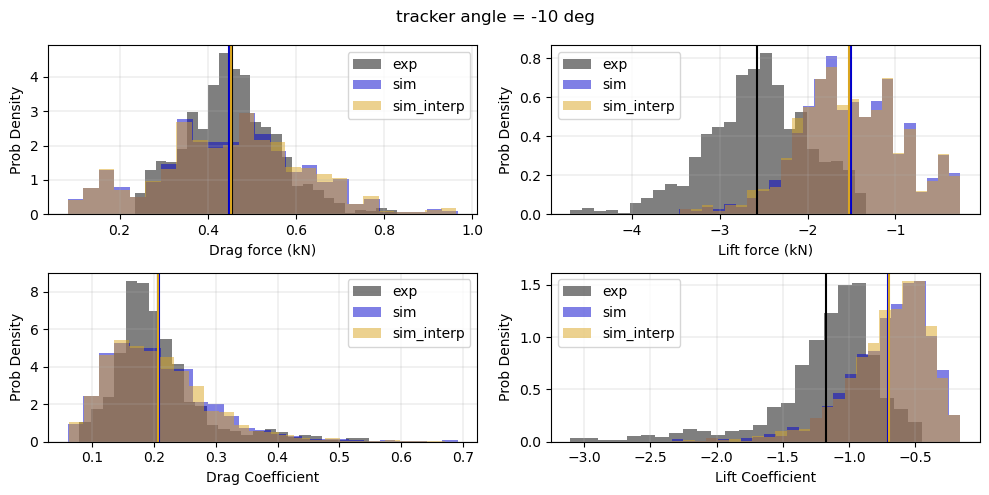

In [65]:
# histograms
time_threshold = 2.0

vars = ['Drag force (kN)', 'Lift force (kN)', 
        'Drag Coefficient', 'Lift Coefficient']
nbins = 25

for tilt in tilts:
    # for k,angle in enumerate(float_list_to_str_list(tracker_angles0)):
    fig, axs = plt.subplots(2,2,figsize=[10,5]) #, dpi=300) #, sharey=True)
    plt.suptitle(f'tracker angle = {int(tilt)} deg')
    # plt.suptitle(f'data after {time_threshold} s')
    # for j,u in enumerate(float_list_to_str_list(u_refs0)):
    
    statistics_list = []
    
    for var,ax in zip(vars, axs.ravel()):
        for key in alldata[tilt].keys():
            pltdata = alldata[tilt][key][var][alldata[tilt][key][var].index > time_threshold]
            
            ax.hist(pltdata, bins=nbins, density=True, alpha=0.5, label=key, color=colors[key])
            ax.axvline(np.mean(pltdata.values), color=colors[key], label='')
            ax.set_xlabel(var)
            ax.legend()
    
    for ax in axs.ravel():
        ax.grid(lw=0.25)
        ax.legend()
        ax.set_ylabel('Prob Density')
    
    # # for ax in axs:
    # axs[-1].set_xlabel('time [s]')
    
    plt.tight_layout()

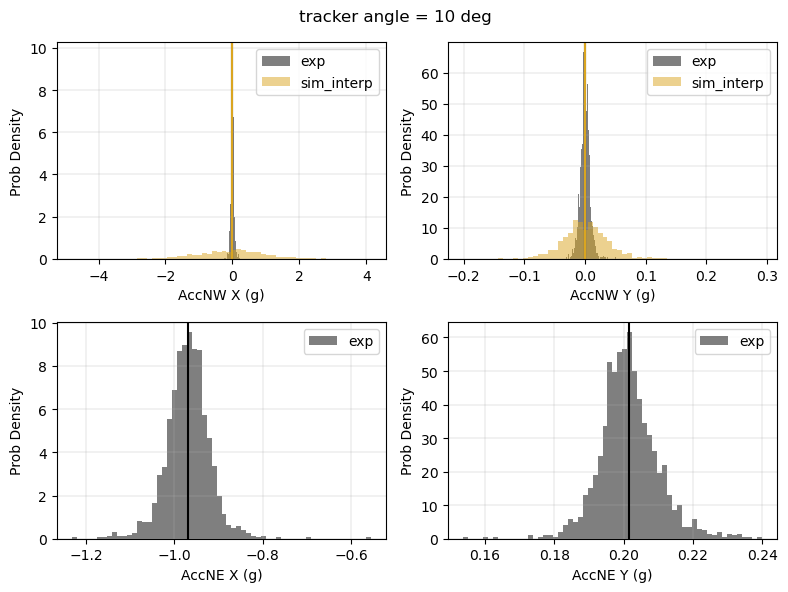

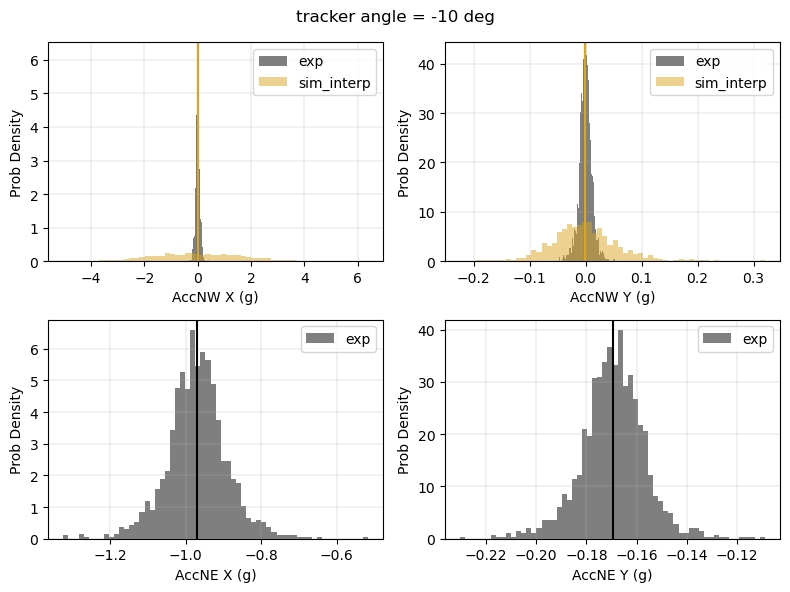

In [94]:
# histograms
time_threshold = 2.0

keys = ['exp', 'sim_interp'] # alldata.keys() #['sim']
vars = ['AccNW X (g)', 'AccNW Y (g)', 'AccNE X (g)', 'AccNE Y (g)']
# vars = ['AccNE X (g)', 'AccNE Y (g)']
nbins = 60

# for k,angle in enumerate(float_list_to_str_list(tracker_angles0)):
# fig, axs = plt.subplots(len(vars),1,figsize=[6,6], sharex=True) #, dpi=300) #, sharey=True)
# plt.suptitle(f'data after {time_threshold} s')
# # for j,u in enumerate(float_list_to_str_list(u_refs0)):

for tilt in tilts:
    fig, axs = plt.subplots(2,2,figsize=[8,6]) #, sharex=True) #, dpi=300) #, sharey=True)
    plt.suptitle(f'tracker angle = {int(tilt)} deg')
    for var,ax in zip(vars, axs.ravel()):
        for key in keys:
            if var in alldata[tilt][key].keys():
                pltdata = alldata[tilt][key][var][alldata[tilt][key][var].index > time_threshold]
                
                ax.hist(pltdata, bins=nbins, density=True, alpha=0.5, label=key, color=colors[key])
                ax.axvline(np.mean(pltdata.values), color=colors[key], label='')
            ax.set_xlabel(var)
            ax.legend()
    
    for ax in axs.ravel():
        ax.grid(lw=0.25)
        ax.legend()
        ax.set_ylabel('Prob Density')
    
    # # for ax in axs:
    # axs[-1].set_xlabel('time [s]')

    plt.tight_layout()

In [69]:
# compute flow metrics
def compute_TI(u,v,w):
    umag = (u**2 + v**2 + w**2)**0.5
    
    Iu = np.std(u, axis=0) / np.mean(umag, axis=0)
    Iv = np.std(v, axis=0) / np.mean(umag, axis=0)
    Iw = np.std(w, axis=0) / np.mean(umag, axis=0)

    return Iu, Iv, Iw

# Collect TI data for each dataset
TI_list = []  # Empty list to hold the results for the DataFrame

for tilt in tilts:
    for key in alldata[tilt].keys():
        Iu, Iv, Iw = compute_TI(alldata[tilt][key]['u (m/s)'], alldata[tilt][key]['v (m/s)'], alldata[tilt][key]['w (m/s)'])
        
        # Append the results as a dictionary to the list
        TI_list.append({
            'Tilt': tilt,
            'Key': key,  # Use `key` to identify the dataset
            'Iu': round(Iu, 3),
            'Iv': round(Iv, 3),
            'Iw': round(Iw, 3)
        })

# Convert the list of dictionaries to a DataFrame
TI_df = pd.DataFrame(TI_list).set_index('Key')

# Print the resulting DataFrame
TI_df

,Tilt,Iu,Iv,Iw
Key,,,,
exp,10.0,0.184,0.152,0.090
sim,10.0,0.218,0.221,0.132
sim_interp,10.0,0.215,0.219,0.128
exp,-10.0,0.186,0.194,0.079
sim,-10.0,0.210,0.170,0.101
sim_interp,-10.0,0.208,0.167,0.095


In [70]:
# Smooth high frequency region
def runningMeanFast(x, N):
    """
    Calculates the running mean of an array x over a window size N.

    Returns:
        np.ndarray: Smoothed signal
    """
    return np.convolve(x, np.ones(N)/N, mode='same') 

def compute_spectra(u, U_mean, height, fs, overlap):
    """
    Computes the normalized energy spectrum of a velocity time series `u`,
    smooths the high-frequency tail, and returns the normalized frequency
    and smoothed normalized power spectral density.

    Parameters:
        u (array-like): Time series of velocity fluctuations (1D)
        U_mean (float): Mean flow velocity (for normalization)
        height (float): Reference height (for normalization)
        fs (float): Sampling frequency [Hz]
        overlap (int): Number of samples to overlap in Welch’s method

    Returns:
        nf_U_corr (np.ndarray): Normalized frequency array
        nPxxf_mod_U_corr (list of np.ndarray): Concatenated original and smoothed
            normalized power spectral density
    """

    # Length of the input time series (used for FFT size and window)
    nblock = len(u)

    # Use a Hamming window for spectral estimation
    win = np.hamming(math.floor(nblock/10))

    # Convert u to a pandas Series for easier handling (e.g., dropna, stats)
    U_corr = pd.Series(u)
    # do I need to detrend this? - probably not bc of "detrend = constant" in welch function call

    # Standard deviation of the fluctuations (used to normalize PSD)
    u_std = U_corr.std()

    # Compute power spectral density using Welch's method
    f_U_corr, Pxxf_U_corr = welch(U_corr.dropna(), fs, window=win, noverlap=overlap, nfft=nblock, detrend='constant', return_onesided=True) # detrend constant removes mean (zero-mean segments)
    
    # Normalize frequency: non-dimensional frequency = f * z / U_mean
    nf_U_corr = f_U_corr*height/abs(U_mean)

    # Normalize power: dimensionless spectral density
    nPxxf_U_corr = (f_U_corr*Pxxf_U_corr)/u_std**2

    # Identify index where normalized frequency > 0.3 (start smoothing here)
    index_highfreq_U_corr = list(np.where([abs(nf_U_corr)>0.3]))

    # Extract the high-frequency tail to smooth
    nPxxf_smooth_U_corr = nPxxf_U_corr[index_highfreq_U_corr[0][0]:len(nPxxf_U_corr)]

    # Apply running mean to smooth the high-frequency region
    avg_window_size = int(nblock/6)
    nPxxf_smooth_U_corr = runningMeanFast(nPxxf_smooth_U_corr,avg_window_size) # 200)

    # Concatenate the low-frequency part (unsmoothed) with the smoothed tail
    # nPxxf_mod_U_corr = [nPxxf_U_corr[0:index_highfreq_U_corr[0][0]-1],nPxxf_smooth_U_corr]
    nPxxf_mod_U_corr = nPxxf_U_corr # without smoothing

    # return nf_U_corr, nPxxf_mod_U_corr
    return nf_U_corr, nPxxf_mod_U_corr

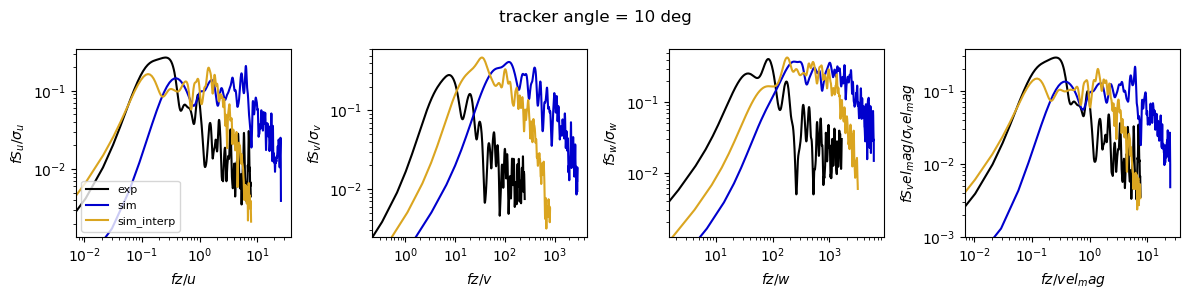

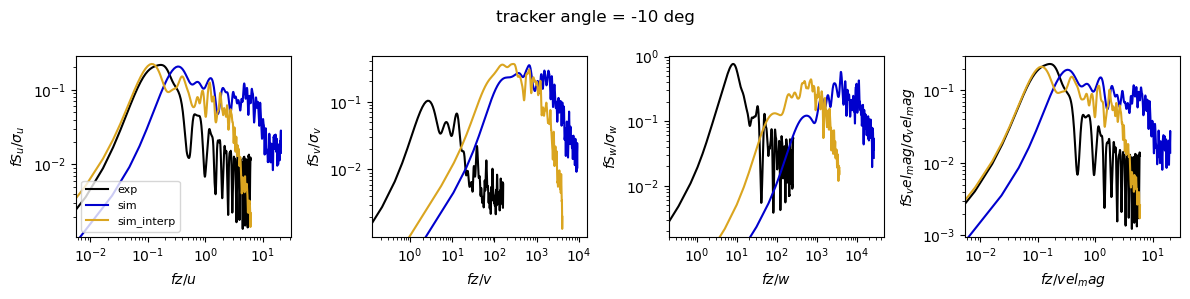

In [72]:
# spectra of flow
vars = alldata[tilt].keys()
comps = ['u','v','w','vel_mag']

for tilt in tilts:
    fs = {'exp': 50, 'sim': 1/params[tilt]['dt_sim'], 'sim_interp': 50} # Hz
    overlap = 0
    
    nf_corr = {}; nPxxf_mod_corr = {}
    U_mean = {}
    
    for var in vars:
        U_mean[var] = {}
        for comp in comps:
            # Compute the mean while ignoring NaN values
            U_mean[var][comp] = float(np.nanmean(alldata[tilt][var][comp+' (m/s)'].values))
    
    for var in vars:
        nf_corr[var] = {}
        nPxxf_mod_corr[var] = {}
        for comp in comps:
            nf_corr[var][comp], nPxxf_mod_corr[var][comp] = compute_spectra(alldata[tilt][var][comp+' (m/s)'].values.squeeze(), U_mean[var][comp], zloc, fs[var], overlap)
            
    fig, axs = plt.subplots(1,4, figsize=[12,3]) #, sharey=True)
    plt.suptitle(f'tracker angle = {int(tilt)} deg')
    
    for var in vars:
        for comp,ax in zip(comps, axs.ravel()):
            # ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp][1])]), nPxxf_mod_corr[var][comp][1], color=colors[var], label=var)       
            ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp])]), nPxxf_mod_corr[var][comp], color=colors[var], label=var)            
            ax.set_xlabel(f"$fz/{comp}$")
            ax.set_ylabel(f"$fS_{comp}/\\sigma_{comp}$")
    axs[0].legend(loc='lower left',fontsize=8)
    # axs[0].set_title('streamwise u spectra')
    # axs[0].set_xlim(10e-3, 10e-1)
    # axs[0].set_ylim(10e-3, 10e-1)
    plt.tight_layout()

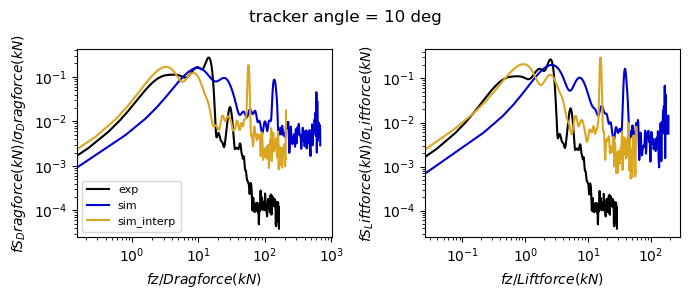

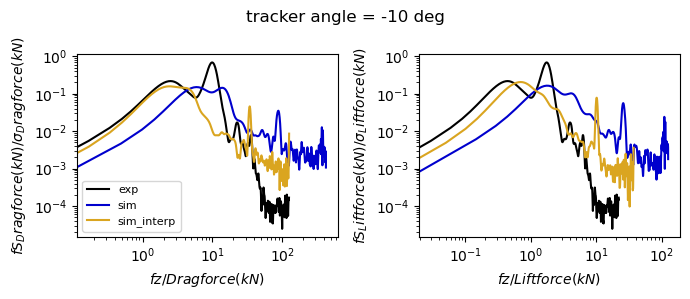

In [74]:
# spectra of loads
vars = alldata[tilt].keys()
comps = ['Drag force (kN)', 'Lift force (kN)']

for tilt in tilts:
    fs = {'exp': 50, 'sim': 1/params[tilt]['dt_sim'], 'sim_interp': 50} # Hz
    overlap = 0
    
    nf_corr = {}; nPxxf_mod_corr = {}
    comp_mean = {}
    
    for var in vars:
        comp_mean[var] = {}
        for comp in comps:
            # Compute the mean while ignoring NaN values
            comp_mean[var][comp] = float(np.nanmean(alldata[tilt][var][comp].values))
    
    for var in vars:
        nf_corr[var] = {}
        nPxxf_mod_corr[var] = {}
        for comp in comps:
            nf_corr[var][comp], nPxxf_mod_corr[var][comp] = compute_spectra(alldata[tilt][var][comp].values.squeeze(), comp_mean[var][comp], zloc, fs[var], overlap)
            
    fig, axs = plt.subplots(1,2, figsize=[7,3]) #, sharey=True)
    plt.suptitle(f'tracker angle = {int(tilt)} deg')
    
    for var in vars:
        for comp,ax in zip(comps, axs.ravel()):
            # ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp][1])]), nPxxf_mod_corr[var][comp][1], color=colors[var], label=var)       
            ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp])]), nPxxf_mod_corr[var][comp], color=colors[var], label=var)            
            ax.set_xlabel(f"$fz/{comp}$")
            ax.set_ylabel(f"$fS_{comp}/\\sigma_{comp}$")
    axs[0].legend(loc='lower left',fontsize=8)
    # axs[0].set_title('streamwise u spectra')
    # axs[0].set_xlim(10e-3, 10e-1)
    # axs[0].set_ylim(10e-3, 10e-1)
    plt.tight_layout()

In [ ]:
# # first glance at drag and lift forces
# plt.style.use('default')
# time_threshold = 2.0 #12.0 # s

# vars = ['Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient']
# colors = {'exp': 'k', 'sim': 'mediumblue', 'sim_interp': 'goldenrod'}
# keys = ['sim','sim_interp','exp']

# fig, axs = plt.subplots(2,2,figsize=[10,5],sharex=True) #, dpi=300) #, sharey=True)
# # plt.suptitle('u='+u+' m/s')
# # for n,var in enumerate(vars):
# for var,ax in zip(vars, axs.ravel()):
#     for key in keys:
#         pltdata = alldata[key][var][alldata[key][var].index > 2.0]
#         ax.plot(pltdata, label=key, color=colors[key])
#         ax.axvline(time_threshold, linestyle=':', color='k')
#         ax.set_ylabel(var)
#         # ax.legend()
#         # axs[0].set_xlim([15, 20])
#         # axs[0].set_ylim([0.0, 4.0])

# for ax in axs.ravel():
#     ax.grid(lw=0.25)
#     # ax.legend()

# for ax in axs[-1,:]:
#     ax.set_xlabel('time [s]')

# axs[-1,-1].legend()

# plt.tight_layout()

In [ ]:
# # plot velocity signals
# fig, axs = plt.subplots(4,1, figsize=[8,6], sharex=True)

# comps = ['u','v','w','vel_mag']
# vars = ['sim','sim_interp','exp']
# # vars = ['exp']

# for comp,ax in zip(comps, axs.ravel()):
#     for var in vars:
#         ax.plot(alldata[var][comp+' (m/s)'], label=var, alpha=0.8, color=colors[var])
#         ax.set_ylabel(f"{comp} [m/s]")
#     ax.grid(lw=0.5)
# axs[0].legend()
# axs[-1].set_xlabel("time [s]")
# plt.tight_layout()

In [ ]:
# # if needed for debugging: plot signal from h5 file and sonic
# import h5py

# turb_h5_fname = '/projects/pvopt/aps_dfd_2024/PVade/input/pct_constrained_turb_ny154_nz38_sonic1_30s_u9.0_50Hz.h5'
# sim_turb_data = {}

# with h5py.File(turb_h5_fname, "r") as fp:
#     for key, val in fp.items():
#         print(key, val.shape, val.dtype)

#     t_fp = fp["time_index"][:]
#     y_fp = fp["y_coordinates"][:]
#     z_fp = fp["z_coordinates"][:]

#     # comp="u"
#     # fig, ax = plt.subplots()
#     # plt.suptitle('pyconturb flowfield')
#     # plt.imshow(fp[comp][0, :, :],  # imshow requires nz-ny slice
#     #             origin='lower',  # smallest y-z in lower left, not upper left
#     #             extent=[y_fp[0], y_fp[-1], z_fp[0], z_fp[-1]],  # lateral and vertical limits
#     #             interpolation='bilinear',
#     #             cmap='coolwarm')  # image smoothing
#     # plt.colorbar(label=comp)

#     sim_turb_data["u"] = fp["u"][:, :, :]
#     sim_turb_data["v"] = fp["v"][:, :, :]
#     sim_turb_data["w"] = fp["w"][:, :, :]

# jp = int(np.argmin(np.abs(y_fp - yloc)))
# kp = int(np.argmin(np.abs(z_fp - zloc)))
# # print(f'comparing timeseries at (y,z) = ({y_fp[jp]:.2f},{z_fp[kp]:.2f}) to sonic loc of ({yloc:.2f},{zloc:.2f})')

# fig, axs = plt.subplots(3,1, figsize=[8,6], sharex=True)
# plt.suptitle(f'comparing timeseries at (y,z) = ({y_fp[jp]:.2f},{z_fp[kp]:.2f}) to sonic loc of ({yloc:.2f},{zloc:.2f})')
# for comp,ax in zip(['u','v','w'], axs.ravel()):
#     ax.plot(t_fp,sim_turb_data[comp][:,kp,jp], label='pyconturb')
#     ax.plot(alldata['sim'][comp+' (m/s)'], label='pvade at inlet')
#     ax.plot(alldata['exp'][comp+' (m/s)'], 'k', label='experimental')
#     ax.set_ylabel(f"{comp} [m/s]")
#     ax.grid(lw=0.5)
# axs[0].legend()
# axs[-1].set_xlabel("time [s]")
# plt.tight_layout()